# Evaluation of Resampling Methods on Imbalanced OCPP Dataset

This notebook implements a systematic evaluation of different resampling strategies to address class imbalance in an Intrusion Detection System (IDS) context. The dataset is derived from OCPP 1.6 traffic flows preprocessed with **OCPPFlowMeter**, containing labeled samples of normal and attack classes.

The workflow includes:
- **Dataset loading and preprocessing**: removal of constant/zero-only columns, conversion of flow duration, and preparation of training/test sets.
- **Resampling techniques**: application of oversampling, undersampling, and hybrid methods, including:
  - SMOTE and its variants (SMOTE, ADASYN, SMOTE+ENN, SMOTE+Tomek)
  - Random Undersampling (RUS)
  - NearMiss (v1, v2, v3)
- **Classification model**: evaluation based on **k-Nearest Neighbors (kNN)** with fixed hyperparameters.
- **Evaluation protocol**: performance metrics are computed across varying percentages of minority-class retention, including:
  - Accuracy
  - Balanced Accuracy
  - Precision, Recall, and F1-score (per class)
  - ROC AUC
- **Visualization and analysis**: generation of comparative plots (subplots by technique, recall vs. % class 0, etc.) and CSV/PNG outputs for further analysis.

The main objective is to quantify the impact of different resampling methods on classifier performance under severe imbalance scenarios, providing insights into which techniques are most effective for IDS in EV charging infrastructures.

# Imports

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from typing import List, Tuple, Dict
from sklearn.impute import SimpleImputer

## Files and folders

In [125]:
# Train and test
train_file = "Train1.csv"
test_file  = "Test1.csv"

# Results folder
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

## Helper functions

In [126]:

def convert_duration(df: pd.DataFrame) -> pd.DataFrame:
    if "flow_duration" in df.columns:
        df["flow_duration"] = df["flow_duration"] / 1e9  # ns → s
    return df

def add_label_bin(df: pd.DataFrame) -> pd.DataFrame:
    # Binary labels: 1 = attack, 0 = normal
    if "label" in df.columns and "label_bin" not in df.columns:
        df['label_bin'] = df['label'].apply(lambda x: 1 if 'cyberattack' in str(x).lower() else 0)
    return df

def detailed_constant_columns(df: pd.DataFrame) -> Dict[str, str]:
    report = {}
    for c in df.columns:
        s = df[c]
        uniques = s.dropna().unique()

        if s.isna().all():
            report[c] = "all NaN"
        elif len(uniques) == 1:
            val = uniques[0]
            if val == 0:
                report[c] = "all zeros"
            else:
                report[c] = f"constant value: {val}"
        elif s.nunique(dropna=False) == 1:
            val = uniques[0] if len(uniques) > 0 else "NaN"
            report[c] = f"constant (with NaN): {val}"
    return report

def drop_selected_columns(df: pd.DataFrame, cols_to_drop: List[str]) -> pd.DataFrame:
    return df.drop(columns=cols_to_drop, errors="ignore")

# --- Imputer ---
def fit_imputers_on_train(df_train: pd.DataFrame):
    """Fit separate imputers for int and float columns on TRAIN."""
    int_cols = df_train.select_dtypes(include=['int', 'int32', 'int64']).columns.tolist()
    float_cols = df_train.select_dtypes(include=['float', 'float32', 'float64']).columns.tolist()

    # Exclude label_bin if present
    if "label_bin" in int_cols:
        int_cols.remove("label_bin")

    imputer_int = SimpleImputer(strategy="most_frequent") if int_cols else None
    imputer_float = SimpleImputer(strategy="mean") if float_cols else None

    if int_cols:
        imputer_int.fit(df_train[int_cols])
    if float_cols:
        imputer_float.fit(df_train[float_cols])

    return imputer_int, imputer_float, int_cols, float_cols


def apply_imputers(df: pd.DataFrame,
                   imputer_int: SimpleImputer, int_cols: List[str],
                   imputer_float: SimpleImputer, float_cols: List[str]) -> pd.DataFrame:
    """Apply fitted imputers to TRAIN or TEST, preserving dtypes."""
    df_copy = df.copy()

    if int_cols and imputer_int is not None:
        df_copy[int_cols] = imputer_int.transform(df_copy[int_cols]).astype(int)
    if float_cols and imputer_float is not None:
        df_copy[float_cols] = imputer_float.transform(df_copy[float_cols]).astype(float)

    return df_copy

def timestamp_evaluation(df: pd.DataFrame, ts_cols: List[str]) -> None:
    print("\n--- Timestamp Column Evaluation ---")
    for col in ts_cols:
        if col in df.columns:
            print(f"\n{col}:")
            print(f"  min: {df[col].min():.0f}")
            print(f"  max: {df[col].max():.0f}")
            print(f"  mean: {df[col].mean():.0f}")
            print(f"  std: {df[col].std():.0f}")
            print(f"  range: {df[col].max() - df[col].min():.0f}")
            print(f"  is_monotonic: {df[col].is_monotonic_increasing}")

def timestamp_correlations(df: pd.DataFrame) -> None:
    if 'flow_duration' in df.columns and 'label_bin' in df.columns:
        for col in ['flow_start_timestamp', 'flow_end_timestamp']:
            if col in df.columns:
                print(f"\nCorrelation with flow_duration:")
                print(f"  {col.replace('_', ' ')} vs duration: {df[col].corr(df['flow_duration']):.4f}")
                print(f"\nCorrelation with label_bin:")
                print(f"  {col.replace('_', ' ')} vs label_bin: {df[col].corr(df['label_bin']):.4f}")

## Load and clean TRAIN

In [127]:
df_train = pd.read_csv(train_file)
print("Original TRAIN shape:", df_train.shape)

# Columns to drop known to be IDs or timestamps
cols_to_drop = ['flow_id', 'src_ip', 'dst_ip', 'src_port', 'dst_port']
timestamp_columns = ['flow_start_timestamp', 'flow_end_timestamp']

# Timestamp eval
timestamp_evaluation(df_train, timestamp_columns)

timestamp_correlations(df_train)

# Drop selected columns
df_train = drop_selected_columns(df_train, cols_to_drop + timestamp_columns)

df_train = convert_duration(df_train)
df_train = add_label_bin(df_train)

# Impute NaNs using TRAIN means
# Fit imputers separately for int and float
imputer_int, imputer_float, int_cols, float_cols = fit_imputers_on_train(df_train)

# Apply imputers to TRAIN
df_train = apply_imputers(df_train, imputer_int, int_cols, imputer_float, float_cols)

# Detect constant/zero/NaN-only columns in TRAIN
useless_report = detailed_constant_columns(df_train)
print("Useless columns detected in TRAIN with reasons:")
for col, reason in useless_report.items():
    print(f" - {col}: {reason}")

const_cols = list(useless_report.keys())

# Columns to drop globally
to_drop = list(set(cols_to_drop + timestamp_columns + const_cols))
df_train_clean = drop_selected_columns(df_train, to_drop)

print("TRAIN after cleaning:", df_train_clean.shape)
print(df_train_clean.head())
df_train_clean.describe().T


Original TRAIN shape: (1007, 55)

--- Timestamp Column Evaluation ---

flow_start_timestamp:
  min: 1682504586666578
  max: 1719316443179113
  mean: 1698220090491237
  std: 17870089736858
  range: 36811856512535
  is_monotonic: False

flow_end_timestamp:
  min: 1682504706327633
  max: 1719316493125460
  mean: 1698220173771609
  std: 17870069950118
  range: 36811786797827
  is_monotonic: False
Useless columns detected in TRAIN with reasons:
 - flow_total_URG_flag: all zeros
 - flow_total_CWE_flag: all zeros
 - flow_total_ECE_flag: all zeros
 - flow_total_http_5xx_packets: all zeros
 - flow_total_ocpp16_resetHard_packets: all zeros
 - flow_total_ocpp16_resetSoft_packets: all zeros
 - flow_total_ocpp16_unlockconnector_packets: all zeros
 - flow_min_ocpp16_metervalues_soc: all zeros
 - flow_max_ocpp16_metervalues_soc: all zeros
TRAIN after cleaning: (1007, 40)
   total_flow_packets  total_fw_packets  total_bw_packets  flow_duration  \
0                 126                61                

,count,mean,std,min,25%,50%,75%,max
total_flow_packets,1007.0,382.228401,663.267906,2.0,1.300000e+01,4.900000e+01,1.250000e+02,1805.000000
total_fw_packets,1007.0,205.600794,362.057031,1.0,6.000000e+00,2.400000e+01,6.300000e+01,958.000000
total_bw_packets,1007.0,176.627607,303.527052,1.0,5.000000e+00,2.500000e+01,6.300000e+01,958.000000
flow_duration,1007.0,0.083280,0.049248,0.0,3.434948e-02,1.104527e-01,1.195339e-01,0.119998
flow_down_up_ratio,1007.0,0.972802,0.223458,0.2,8.333333e-01,9.841270e-01,1.045455e+00,2.600000
flow_total_SYN_flag,1007.0,0.732870,1.295021,0.0,0.000000e+00,0.000000e+00,0.000000e+00,6.000000
flow_total_RST_flag,1007.0,0.015889,0.125107,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
flow_total_PSH_flag,1007.0,212.076465,372.951984,0.0,7.500000e+00,2.500000e+01,6.500000e+01,971.000000
flow_total_ACK_flag,1007.0,381.723932,663.536156,0.0,1.300000e+01,4.900000e+01,1.250000e+02,1805.000000
flow_total_FIN_flag,1007.0,0.423039,0.818393,0.0,0.000000e+00,0.000000e+00,0.000000e+00,3.000000


## Load and clean TEST (apply same rules)

In [128]:
df_test = pd.read_csv(test_file)
print("Original TEST shape:", df_test.shape)

df_test = convert_duration(df_test)
df_test = add_label_bin(df_test)

# Apply imputers as in TRAIN
df_test = apply_imputers(df_test, imputer_int, int_cols, imputer_float, float_cols)

# Drop same columns as in TRAIN
df_test_clean = drop_selected_columns(df_test, to_drop)

print("TEST after cleaning:", df_test_clean.shape)
df_test_clean.head()

Original TEST shape: (432, 55)
TEST after cleaning: (432, 40)


,total_flow_packets,total_fw_packets,total_bw_packets,flow_duration,flow_down_up_ratio,flow_total_SYN_flag,flow_total_RST_flag,flow_total_PSH_flag,flow_total_ACK_flag,flow_total_FIN_flag,...,flow_min_ocpp16_setchargingprofile_limit,flow_avg_ocpp16_setchargingprofile_minchargingrate,flow_min_ocpp16_setchargingprofile_minchargingrate,flow_max_ocpp16_setchargingprofile_minchargingrate,flow_total_ocpp16_metervalues,flow_avg_ocpp16_metervalues_wh_diff,flow_max_ocpp16_metervalues_wh_diff,flow_min_ocpp16_metervalues_wh_diff,label,label_bin
0,102,50,52,0.099598,1.040000,0,0,53,102,0,...,0,0.0,0,0,6,0.0,0,0,cyberattack_ocpp16_doc_idtag,1
1,76,34,42,0.109955,1.235294,0,0,42,76,0,...,0,0.0,0,0,4,0.0,0,0,cyberattack_ocpp16_doc_idtag,1
2,124,64,60,0.115993,0.937500,0,0,65,124,0,...,0,0.0,0,0,8,0.0,0,0,cyberattack_ocpp16_doc_idtag,1
3,10,5,5,0.008187,1.000000,3,1,2,7,1,...,0,0.0,0,0,0,0.0,0,0,normal,0
4,47,22,25,0.119782,1.136364,0,0,25,47,0,...,10,3.0,3,3,0,0.0,0,0,normal,0


## Column consistency check

In [129]:
diff_train = set(df_train_clean.columns) - set(df_test_clean.columns)
diff_test  = set(df_test_clean.columns) - set(df_train_clean.columns)

print("Columns in TRAIN not in TEST:", diff_train)
print("Columns in TEST not in TRAIN:", diff_test)

assert list(df_train_clean.columns) == list(df_test_clean.columns), \
    "Mismatch between TRAIN and TEST columns"

Columns in TRAIN not in TEST: set()
Columns in TEST not in TRAIN: set()


## Save cleaned datasets

In [130]:
train_file_cleaned = "Train1_cleaned.csv"
test_file_cleaned = "Test1_cleaned.csv"
df_train_clean.to_csv(train_file_cleaned, index=False)
df_test_clean.to_csv(test_file_cleaned, index=False)

print("Cleaned datasets saved.")

Cleaned datasets saved.


## Outlier visualization

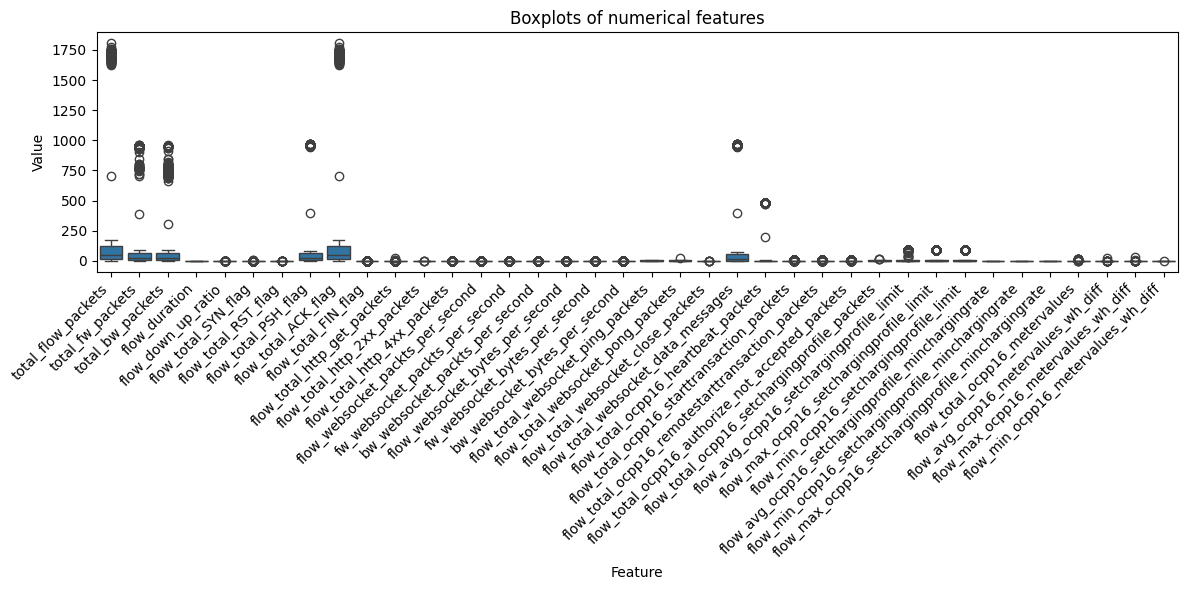

In [131]:
def plot_all_boxplots(df: pd.DataFrame, exclude_cols: List[str]):
    numeric_cols = df.select_dtypes(include=['number']).drop(columns=exclude_cols, errors='ignore').columns.tolist()
    if not numeric_cols:
        print("No numeric columns to plot.")
        return
    X_melted = df[numeric_cols].melt(var_name="Feature", value_name="Value")
    plt.figure(figsize=(12, 6))
    sns.boxplot(x="Feature", y="Value", data=X_melted)
    plt.xticks(rotation=45, ha='right')
    plt.title("Boxplots of numerical features")
    plt.tight_layout()
    plt.show()

plot_all_boxplots(df_train_clean, exclude_cols=["label", "label_bin"])

Outlier data saved to results/outliers_data.csv

Plotting boxplots of numeric features separated by label...


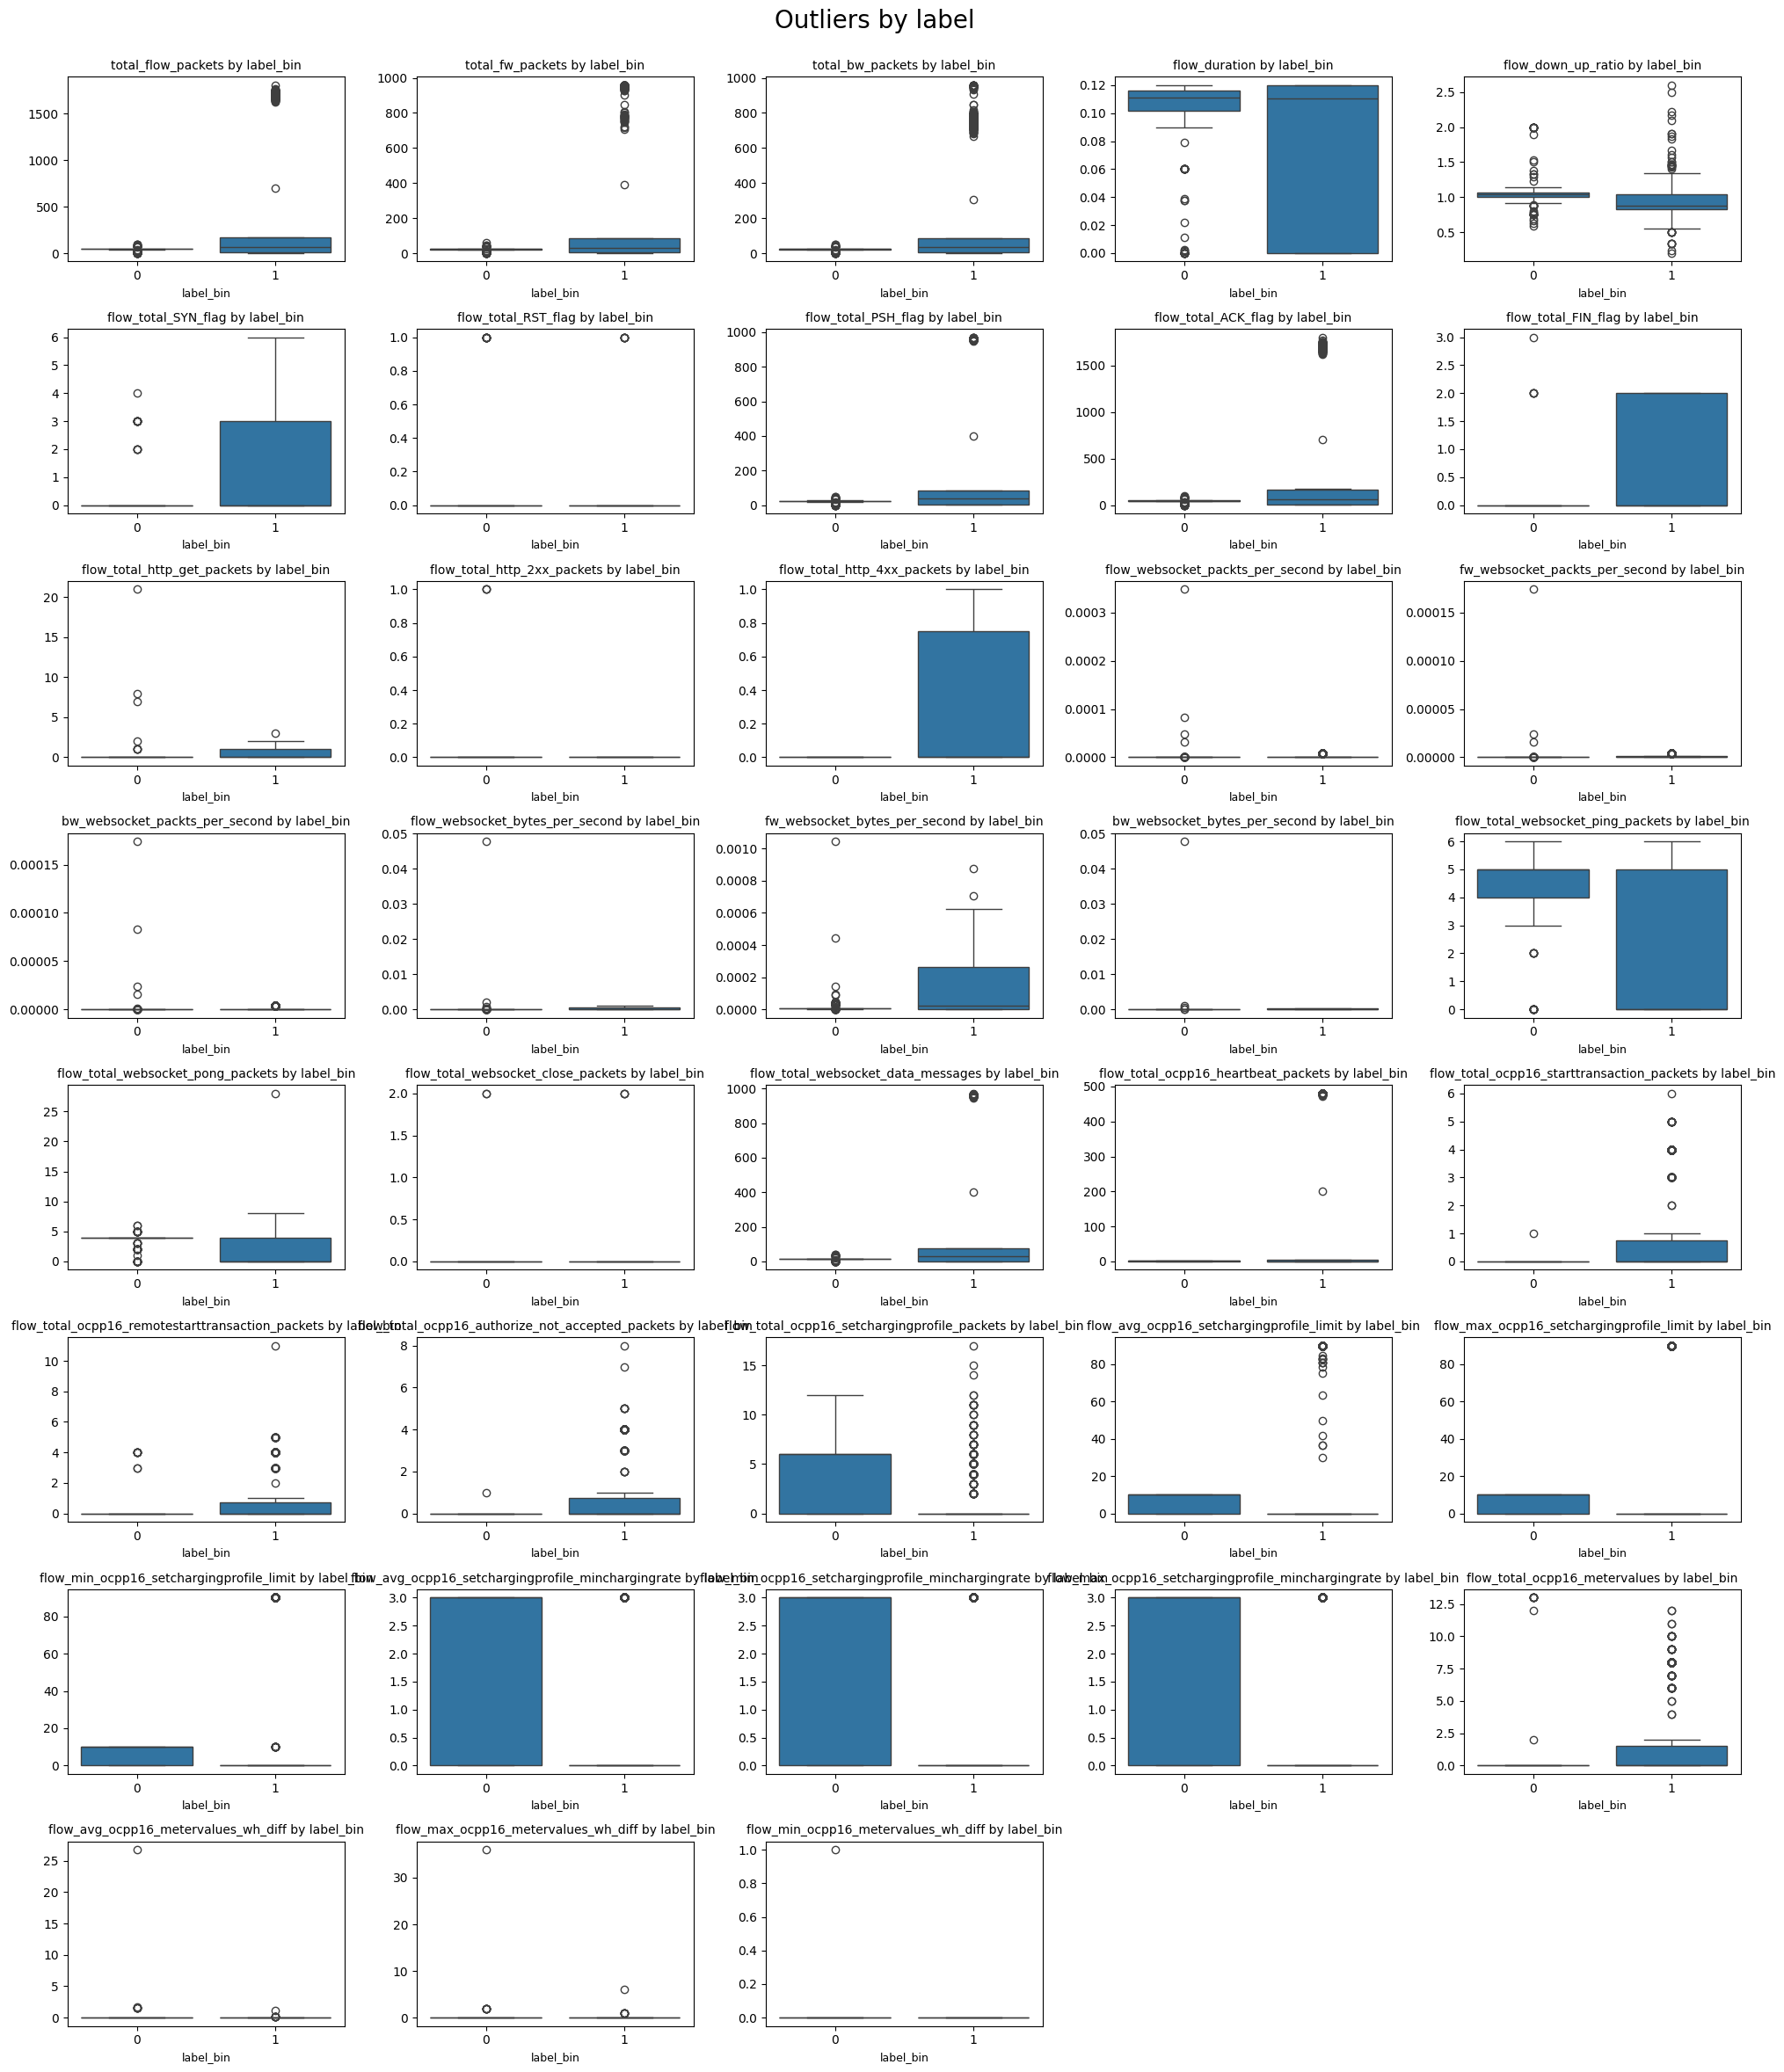

In [132]:
def plot_outliers_by_label(df: pd.DataFrame, label_col: str, exclude_cols: List[str] = []):
    print("\nPlotting boxplots of numeric features separated by label...")

    numeric_cols = (
        df.select_dtypes(include=['number'])
          .drop(columns=exclude_cols + [label_col], errors='ignore')
          .columns.tolist()
    )

    if not numeric_cols:
        print("No numeric columns to plot.")
        return
    
    n_features = len(numeric_cols)
    ncols = 5
    nrows = (n_features + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 3*nrows))
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        sns.boxplot(
            x=label_col,
            y=col,
            data=df,
            ax=axes[i]
        )
        axes[i].set_title(f"{col} by {label_col}", fontsize=10)
        axes[i].tick_params(axis='x', labelrotation=0)
        axes[i].set_xlabel(label_col, fontsize=9)
        axes[i].set_ylabel("", fontsize=9)

    # Eliminar ejes vacíos
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("Outliers by label", fontsize="20")
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

def save_outlier_data(df: pd.DataFrame, label_col: str, exclude_cols: List[str], output_file: str):
    numeric_cols = (
        df.select_dtypes(include=['number'])
          .drop(columns=exclude_cols + [label_col], errors='ignore')
          .columns.tolist()
    )

    if not numeric_cols:
        print("No numeric columns to save.")
        return
    
    # Convert  to long format (feature, label, value)
    df_long = df[[label_col] + numeric_cols].melt(id_vars=label_col,
                                                  var_name="Feature",
                                                  value_name="Value")
    
    output_path = os.path.join(RESULTS_DIR, output_file)
    df_long.to_csv(output_path, index=False)
    print(f"Outlier data saved to {output_path}")

# Save data
save_outlier_data(df_train_clean, label_col="label_bin", exclude_cols=[], output_file="outliers_data.csv")

# Plot data
plot_outliers_by_label(df_train_clean, label_col="label_bin")

## Evaluation of resampling methods
- Class 0 = normal
- Class 1 = attack

### Imports

In [133]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTETomek, SMOTEENN
import matplotlib.patheffects as pe

### Constant strings

In [134]:

PCT_CLASS0='% class 0 in train'
TECHNIQUE='Technique'
BAL_ACC='Balanced Accuracy'
ROC_AUC='ROC AUC'
ACC='Accuracy'
PREC0='Precision (Class 0)'
PREC1='Precision (Class 1)'
REC0='Recall (Class 0)'
REC1='Recall (Class 1)'
F10='F1 (Class 0)'
F11='F1 (Class 1)'
C0_BEFORE='# class 0 before resampling'
C0_AFTER='# Class 0 after resampling'
C1_AFTER='# Class 1 after resampling'
TRAIN_C0='Train Class 0'
UPPER_LEFT = 'upper left'

### Load data

In [135]:
df_train = pd.read_csv(train_file_cleaned)
df_test  = pd.read_csv(test_file_cleaned)

# Drop label column
label_col = ['label']
X_test = df_test.drop(columns=label_col + ['label_bin'], errors='ignore')
y_test = df_test['label_bin']

### Define resampling methods

In [136]:
samplers = {
    "None": None,
    "SMOTE": SMOTE(random_state=13),
    "ADASYN": ADASYN(random_state=13),
    "SMOTE+TomekLinks": SMOTETomek(random_state=13),
    "SMOTE+ENN": SMOTEENN(random_state=13),
    "RUS": RandomUnderSampler(random_state=13),
    "NearMiss-1": NearMiss(version=1),
    "NearMiss-2": NearMiss(version=2),
    "NearMiss-3": NearMiss(version=3)
}

# Percentages of class 0 to keep
percentages = [0.05, 0.1, 0.25, 0.5, 0.75, 1.0]

results = []

### Start the loop for the percentages

In [137]:
from time import perf_counter
from datetime import timedelta
from tqdm.auto import tqdm

def ratio_str(s, decimals: int = 2, as_percent: bool = True, order=(0, 1)):
    """
    Return a compact string showing class counts and class ratios.

    Parameters
    ----------
    s : pd.Series
        Input series of class labels (e.g., 0 and 1).
    decimals : int, optional (default=2)
        Number of decimal places to display in ratios.
    as_percent : bool, optional (default=True)
        If True, show ratios as percentages (e.g., 98.77%).
        If False, show ratios as decimal fractions (e.g., 0.99).
    order : tuple or list, optional (default=(0, 1))
        Explicit order of class labels to display. If None, use natural order
        from the data (value_counts index).

    Returns
    -------
    str
        String with both class counts and class ratios, formatted consistently.
        Example: "counts={ 0: 10, 1: 90 } ratios={ 0: 10.00%, 1: 90.00% }"
    """

    # Return empty if the series has no elements
    if len(s) == 0:
        return "{}"

    # Absolute counts of each class
    vc = s.value_counts()

    # Relative frequencies (normalized counts)
    rn = s.value_counts(normalize=True)

    # Helper function to format each ratio with desired decimals/percent
    def fmt(v: float) -> str:
        x = float(v) * (100 if as_percent else 1)  # convert to percent if needed
        return f"{x:.{decimals}f}" + ("%" if as_percent else "")

    # Determine the order of classes to display
    keys = order if order is not None else list(rn.index)

    # Build string for counts in the given order
    counts_str = ", ".join(f"{k}: {int(vc.get(k, 0))}" for k in keys)

    # Build string for ratios in the given order
    ratios_str = ", ".join(f"{k}: {fmt(rn.get(k, 0.0))}" for k in keys)

    # Final compact string
    return f"counts={{ {counts_str} }} ratios={{ {ratios_str} }}"

results = []

# Main progress bar: percentages
for pct in tqdm(percentages, desc="Reducing class 0 (%)"):
    t_pct0 = perf_counter()
    print(f"\n=== PCT {int(pct*100)}% ===")

    # Build reduced dataset
    if pct == 1.0:
        df_reduced = df_train.copy()
    else:
        df_0 = df_train[df_train['label_bin'] == 0]
        df_1 = df_train[df_train['label_bin'] == 1]
        n_samples = int(len(df_0) * pct)
        df_0_down = df_0.sample(n=n_samples, random_state=13)
        df_reduced = pd.concat([df_1, df_0_down]).sample(frac=1, random_state=13)

    # Prepare X/y and align test columns
    X_train = df_reduced.drop(columns=label_col + ['label_bin'], errors='ignore')
    y_train = df_reduced['label_bin']
    X_test_aligned = X_test.reindex(columns=X_train.columns, fill_value=0)

    # Diagnostic: dataset sizes and class ratios
    print(f"[build] X_train={X_train.shape} X_test_aligned={X_test_aligned.shape} "
          f"| y_train {ratio_str(y_train)} | y_test {ratio_str(y_test)}")

    # Choose scaler
    scaler = StandardScaler()
    # scaler = RobustScaler()

    # Secondary progress bar: samplers
    pbar = tqdm(samplers.items(), leave=False)
    for sampler_name, sampler in pbar:
        # change the text shown at the left of the bar
        pbar.set_description(f"{sampler_name} @ {int(pct*100)}%")
        
        t_sam0 = perf_counter()

        # Build pipeline
        if sampler is None:
            pipe = SkPipeline([
                ('scaler', scaler),
                ('clf', KNeighborsClassifier())
            ])
            # Distribution after "resampling" (none here, just original y_train)
            y_res = y_train
        else:
            pipe = ImbPipeline([
                ('scaler', scaler),
                ('sampler', sampler),
                ('clf', KNeighborsClassifier())
            ])
            # Try sampler alone to inspect resulting distribution
            try:
                _, y_res = sampler.fit_resample(X_train, y_train)
            except Exception as e:
                print(f"[warn] {sampler_name} failed at {int(pct*100)}%: {e}")
                y_res = pd.Series([], dtype=int)

        # Train + predict
        try:
            pipe.fit(X_train, y_train)
            y_pred  = pipe.predict(X_test_aligned)
            y_score = pipe.predict_proba(X_test_aligned)[:, 1]
        except Exception as e:
            # Log and continue without breaking the loop
            dt = timedelta(seconds=perf_counter() - t_sam0)
            print(f"[error] {sampler_name} @ {int(pct*100)}% failed during fit/predict "
                  f"after {dt}: {e}")
            continue

        # Metrics
        recall_class0 = recall_score(y_test, y_pred, pos_label=0)
        recall_class1 = recall_score(y_test, y_pred, pos_label=1)

        results.append({
            PCT_CLASS0: int(pct * 100),
            TECHNIQUE: sampler_name,
            BAL_ACC: balanced_accuracy_score(y_test, y_pred),
            ROC_AUC: roc_auc_score(y_test, y_score),
            ACC: accuracy_score(y_test, y_pred),
            PREC0: precision_score(y_test, y_pred, pos_label=0, zero_division=0),
            PREC1: precision_score(y_test, y_pred, pos_label=1, zero_division=0),
            REC0: recall_class0,
            REC1: recall_class1,
            F10: f1_score(y_test, y_pred, pos_label=0, zero_division=0),
            F11: f1_score(y_test, y_pred, pos_label=1, zero_division=0),
            C0_AFTER: int(np.sum(y_res == 0)) if len(y_res) else 0,
            C1_AFTER: int(np.sum(y_res == 1)) if len(y_res) else 0
        })

        dt = timedelta(seconds=perf_counter() - t_sam0)
        print(f"[done] {sampler_name:>12} @ {int(pct*100)}% | "
              f"after={dt} | y_res {ratio_str(y_res)}")

    # Time spent per percentage
    dt_pct = timedelta(seconds=perf_counter() - t_pct0)
    print(f"[pct-done] {int(pct*100)}% completed in {dt_pct}")


Reducing class 0 (%):   0%|          | 0/6 [00:00<?, ?it/s]


=== PCT 5% ===
[build] X_train=(816, 38) X_test_aligned=(432, 38) | y_train counts={ 0: 10, 1: 806 } ratios={ 0: 1.23%, 1: 98.77% } | y_test counts={ 0: 86, 1: 346 } ratios={ 0: 19.91%, 1: 80.09% }


[done]         None @ 5% | after=0:00:00.057257 | y_res counts={ 0: 10, 1: 806 } ratios={ 0: 1.23%, 1: 98.77% }
[done]        SMOTE @ 5% | after=0:00:00.095328 | y_res counts={ 0: 806, 1: 806 } ratios={ 0: 50.00%, 1: 50.00% }


[done]       ADASYN @ 5% | after=0:00:00.167855 | y_res counts={ 0: 806, 1: 806 } ratios={ 0: 50.00%, 1: 50.00% }
[done] SMOTE+TomekLinks @ 5% | after=0:00:00.148314 | y_res counts={ 0: 806, 1: 806 } ratios={ 0: 50.00%, 1: 50.00% }


[done]    SMOTE+ENN @ 5% | after=0:00:00.364480 | y_res counts={ 0: 806, 1: 803 } ratios={ 0: 50.09%, 1: 49.91% }
[done]          RUS @ 5% | after=0:00:00.024514 | y_res counts={ 0: 10, 1: 10 } ratios={ 0: 50.00%, 1: 50.00% }
[done]   NearMiss-1 @ 5% | after=0:00:00.031505 | y_res counts={ 0: 10, 1: 10 } ratios={ 0: 50.00%, 1: 50.00% }
[done]   NearMiss-2 @ 5% | after=0:00:00.070805 | y_res counts={ 0: 10, 1: 10 } ratios={ 0: 50.00%, 1: 50.00% }


...

[done]       ADASYN @ 100% | after=0:00:00.087503 | y_res counts={ 0: 807, 1: 806 } ratios={ 0: 50.03%, 1: 49.97% }


[done] SMOTE+TomekLinks @ 100% | after=0:00:00.239772 | y_res counts={ 0: 806, 1: 806 } ratios={ 0: 50.00%, 1: 50.00% }


[done]    SMOTE+ENN @ 100% | after=0:00:00.317662 | y_res counts={ 0: 802, 1: 800 } ratios={ 0: 50.06%, 1: 49.94% }
[done]          RUS @ 100% | after=0:00:00.095288 | y_res counts={ 0: 201, 1: 201 } ratios={ 0: 50.00%, 1: 50.00% }
[done]   NearMiss-1 @ 100% | after=0:00:00.076627 | y_res counts={ 0: 201, 1: 201 } ratios={ 0: 50.00%, 1: 50.00% }


/home/106397@TRI.LAN/Título propio UPV/venv-tfm/lib/python3.12/site-packages/imblearn/under_sampling/_prototype_selection/_nearmiss.py:206: UserWarning: The number of the samples to be selected is larger than the number of samples available. The balancing ratio cannot be ensure and all samples will be returned.
  warnings.warn(
/home/106397@TRI.LAN/Título propio UPV/venv-tfm/lib/python3.12/site-packages/imblearn/under_sampling/_prototype_selection/_nearmiss.py:206: UserWarning: The number of the samples to be selected is larger than the number of samples available. The balancing ratio cannot be ensure and all samples will be returned.
  warnings.warn(
Reducing class 0 (%): 100%|██████████| 6/6 [00:06<00:00,  1.09s/it]

[done]   NearMiss-2 @ 100% | after=0:00:00.087428 | y_res counts={ 0: 201, 1: 201 } ratios={ 0: 50.00%, 1: 50.00% }
[done]   NearMiss-3 @ 100% | after=0:00:00.077590 | y_res counts={ 0: 201, 1: 31 } ratios={ 0: 86.64%, 1: 13.36% }
[pct-done] 100% completed in 0:00:01.137495


### Results dataframe
Results exported to ``results/resampling_methods_results.csv``.

In [138]:
results_df = pd.DataFrame(results)

# Add absolute number of class 0 samples before resampling
total_class_0 = df_train[df_train['label_bin'] == 0].shape[0]
results_df[C0_BEFORE] = (
    results_df[PCT_CLASS0] / 100 * total_class_0
).astype(int)
results_df[TRAIN_C0] = (
    results_df[PCT_CLASS0].astype(str)
    + "% (" + results_df[C0_BEFORE].astype(str) + ")"
)

# Export results
output_file = "resampling_methods_results.csv"
output_path = os.path.join(RESULTS_DIR, output_file)
results_df.to_csv(output_path, index=False)

### Mean results table
Results exported to ``results/mean_metrics_by_technique.csv``.

In [139]:
METRICS = [
    BAL_ACC,
    ROC_AUC,
    ACC,
    PREC0,
    PREC1,
    REC0,
    REC1,
    F10,
    F11,
    C0_AFTER,
    C1_AFTER
]
            
def build_mean_metrics_table(results_df, metrics=METRICS, sort_by=None, decimals=3, output_file=None):
    """
    Returns a DataFrame with mean metrics per technique, averaged across all training percentages.
    """
    df = results_df
    
    metrics_present = [m for m in metrics if m in df.columns]
    if not metrics_present:
        raise ValueError("None of the expected metric columns are present in the provided DataFrame.")

    table = (
        df.groupby("Technique")[metrics_present]
          .mean()
          .round(decimals)
    )
    
    # Default sort: by the first present metric
    if sort_by is None:
        sort_by = metrics_present[0]
    table = table.sort_values(by=sort_by, ascending=False)

    if output_file:
        output_path = os.path.join(RESULTS_DIR, output_file)
        table.to_csv(output_path, index=True)

    return table

build_mean_metrics_table(results_df, sort_by=None, output_file="mean_metrics_by_technique.csv")


,Balanced Accuracy,ROC AUC,Accuracy,Precision (Class 0),Precision (Class 1),Recall (Class 0),Recall (Class 1),F1 (Class 0),F1 (Class 1),# Class 0 after resampling,# Class 1 after resampling
Technique,,,,,,,,,,,
ADASYN,0.974,0.976,0.987,0.980,0.989,0.953,0.995,0.966,0.992,806.333,806.000
SMOTE+TomekLinks,0.974,0.976,0.987,0.982,0.988,0.952,0.996,0.966,0.992,806.000,806.000
SMOTE,0.974,0.976,0.987,0.982,0.988,0.952,0.996,0.966,0.992,806.000,806.000
SMOTE+ENN,0.971,0.975,0.986,0.980,0.987,0.948,0.995,0.963,0.991,804.667,800.500
None,0.929,0.975,0.970,0.986,0.967,0.860,0.997,0.915,0.982,88.500,806.000
RUS,0.883,0.949,0.851,0.774,0.977,0.934,0.831,0.808,0.867,88.500,88.500
NearMiss-3,0.855,0.919,0.840,0.684,0.962,0.882,0.829,0.742,0.880,88.500,20.833
NearMiss-1,0.721,0.838,0.561,0.327,0.994,0.986,0.455,0.486,0.604,88.500,88.500
NearMiss-2,0.703,0.772,0.581,0.349,0.963,0.907,0.500,0.489,0.618,88.500,88.500


### Plotting functions

In [140]:
def set_file_name(title: str) -> str:
    """
    Generate a file name from a given title:
      - Replace " | " with "-"
      - Replace " - " with "_"
      - Replace ": " with "_"
      - Replace remaining spaces with "_"
      - Lowercase the result
      - Add ".png" extension
    """
    filename = title.replace(" | ", "-")
    filename = filename.replace(" - ", "_")
    filename = filename.replace(": ", "_")
    filename = filename.replace(" ", "_")
    filename = filename.lower() + ".png"
    filename = os.path.join(RESULTS_DIR, filename)
    return filename

def plot_metric(metric_col, ylabel, title, save_png: bool = True):
    plt.figure(figsize=(10, 5))
    ax = plt.gca()
    sns.lineplot(
        data=results_df,
        x=TRAIN_C0, y=metric_col,
        hue=TECHNIQUE, marker='o', ax=ax
    )
    plt.title(title, fontsize=15)
    plt.xlabel("% of class 0 samples used in training (real count before resampling)")
    plt.xticks(rotation=30)
    plt.ylabel(ylabel)

    # --- Dynamic Y-axis adjustment ---
    y_min = results_df[metric_col].min()
    y_max = results_df[metric_col].max()
    margin = 0.05 * (y_max - y_min)  # 5% margin
    plt.ylim(y_min - margin, y_max + margin)
        
    plt.legend(bbox_to_anchor=(1.05, 1), loc=UPPER_LEFT)
    plt.tight_layout()
    
    if save_png:
        filename = set_file_name(title)
        plt.savefig(filename, dpi=300, bbox_inches="tight")
    
    plt.show()
    
def plot_metric_subplots(
    metric_col: str,
    ylabel: str,
    title: str,
    height_per_plot: float = 1.8,
    annotate: bool = True,
    value_fmt: str = "{:.3f}",
    save_png: bool = True
):
    tmp = results_df.copy()

    if TRAIN_C0 not in tmp.columns:
        tmp[TRAIN_C0] = (
            tmp[PCT_CLASS0].astype(str) + "% (" +
            tmp["# class 0 before resampling"].astype(str) + ")"
        )

    tmp = tmp.sort_values(PCT_CLASS0)
    order_labels = (
        tmp[[TRAIN_C0, PCT_CLASS0]]
        .drop_duplicates()
        .sort_values(PCT_CLASS0)[TRAIN_C0]
        .tolist()
    )

    techniques = tmp["Technique"].unique().tolist()
    n = len(techniques)

    fig, axes = plt.subplots(n, 1, figsize=(9, max(3, height_per_plot*n)), sharey=True)

    if n == 1:
        axes = [axes]

    for idx, (ax, tech) in enumerate(zip(axes, techniques)):
        sub = tmp[tmp["Technique"] == tech].copy()
        sub[TRAIN_C0] = pd.Categorical(sub[TRAIN_C0], categories=order_labels, ordered=True)
        sub = sub.sort_values("Train Class 0")

        sns.lineplot(
            data=sub,
            x="Train Class 0",
            y=metric_col,
            marker="o",
            ax=ax,
            sort=False
        )

        ax.set_title(tech, pad=12)
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, 1.05)
        ax.grid(True, linewidth=0.3, alpha=0.5)

        if idx < n - 1:
            ax.set_xlabel("")
            ax.set_xticklabels([])
        else:
            ax.set_xlabel("% of class 0 samples in training (real count before resampling)")
            ax.tick_params(axis="x", rotation=30)

        if annotate:
            line = ax.lines[0]
            for (x, y) in line.get_xydata():
                if pd.notna(y):
                    ax.annotate(
                        value_fmt.format(y),
                        (x, y),
                        textcoords="offset points",
                        xytext=(0, 6),
                        ha="center",
                        fontsize=8
                    )

    # Ajuste de espacios
    fig.suptitle(title, fontsize=15, y=0.92)
    plt.subplots_adjust(hspace=0.5)
    
    if save_png:
        filename = set_file_name(title)
        plt.savefig(filename, dpi=300, bbox_inches="tight")
    
    plt.show()
    
NEARMISS_RUSS = "NearMiss|RUS"

def plot_class_metrics_by_sampling(
    df: pd.DataFrame,
    metric: str = "f1",                    
    which: str = "oversampling",           
    include_none: bool = True,             
    techniques_whitelist: list[str] | None = None,  # if provided, overrides 'which'
    save_png: bool = True,
    save_csv: bool = True,
):
    """
    Unified plotter for Class-wise metrics (F1 or Recall) across resampling techniques.

    Parameters
    ----------
    df : pandas.DataFrame
        Results table containing columns like TECHNIQUE, PCT_CLASS0, C0_BEFORE, F11/F10, REC1/REC0, etc.
    metric : {"f1", "recall"}
        Which class-wise metric to plot. "f1" -> uses [F11, F10]; "recall" -> uses [REC1, REC0].
    which : {"oversampling", "undersampling", "custom"}
        Technique selector:
        - "oversampling": exclude NearMiss and RUS (and optionally "None" if include_none=False)
        - "undersampling": include only NearMiss-* and RUS
        - "custom": use 'techniques_whitelist'
    include_none : bool
        If True and which="oversampling", keep "None" baseline.
    techniques_whitelist : list[str] | None
        Explicit list of techniques to include. If provided, it overrides 'which'.
    save_png : bool
        Whether to save a PNG file of the figure (filename via set_file_name()).
    save_csv : bool
        Whether to save a CSV with the filtered/ordered rows.

    Returns
    -------
    (ax, plot_df, work_df) : (matplotlib.axes.Axes, pandas.DataFrame, pandas.DataFrame)
        ax: the seaborn/matplotlib Axes
        plot_df: melted dataframe used for plotting (long format)
        work_df: filtered dataframe before melting (wide format)
    """

    # ---- Map metric -> columns, labels, and file name fragments ----
    metric = metric.lower().strip()
    if metric == "f1":
        value_vars = [F11, F10]
        y_label = "F1-Score"
        metric_csv_suffix = "f1_results.csv"
        title_metric_part = "F1-Score Class 1 (solid) vs F1-Score Class 0 (dashed)"
        png_name_suffix = "F1 Scores"
    elif metric == "recall":
        value_vars = [REC1, REC0]
        y_label = "Recall"
        metric_csv_suffix = "recall_results.csv"
        title_metric_part = "Recall Class 1 (solid) vs Recall Class 0 (dashed)"
        png_name_suffix = "Recall"
    else:
        raise ValueError("metric must be 'f1' or 'recall'")

    # ---- Technique selection ----
    if techniques_whitelist is not None:
        mask = df[TECHNIQUE].isin(techniques_whitelist)
        label_kind = "Custom selection"
        title_prefix = "Selected variants"
        csv_name = "custom_" + metric_csv_suffix
    else:
        if which not in {"oversampling", "undersampling"}:
            raise ValueError("which must be 'oversampling' or 'undersampling' when techniques_whitelist is None")

        if which == "undersampling":
            # Simple OR regex without capturing groups avoids warnings
            mask = df[TECHNIQUE].str.contains(NEARMISS_RUSS, na=False)
            label_kind = "Undersampling"
            title_prefix = "Undersampling variants"
            csv_name = "undersampling_" + metric_csv_suffix
        else:  # oversampling
            mask = ~df[TECHNIQUE].str.contains(NEARMISS_RUSS, na=False)
            if not include_none:
                mask &= (df[TECHNIQUE] != "None")
            label_kind = "Oversampling"
            title_prefix = "Oversampling variants"
            csv_name = "oversampling_" + metric_csv_suffix

    work_df = df[mask].copy()
    if work_df.empty:
        raise ValueError("No rows match the selection criteria. Check 'which' or 'techniques_whitelist'.")

    # ---- Consistent X-axis labels ----
    if TRAIN_C0 not in work_df.columns:
        work_df[TRAIN_C0] = (
            work_df[PCT_CLASS0].astype(str) + "% (" +
            work_df[C0_BEFORE].astype(str) + ")"
        )

    # Order X categories by ascending percentage
    work_df["__pct__"] = work_df[PCT_CLASS0]
    order_labels = (
        work_df[[TRAIN_C0, "__pct__"]]
        .drop_duplicates()
        .sort_values("__pct__", ascending=True)[TRAIN_C0]
        .tolist()
    )
    work_df[TRAIN_C0] = pd.Categorical(work_df[TRAIN_C0], categories=order_labels, ordered=True)

    # ---- Melt to long format for seaborn ----
    # value_vars are [F11,F10] or [REC1,REC0] depending on 'metric'
    missing_cols = [c for c in value_vars if c not in work_df.columns]
    if missing_cols:
        raise KeyError(f"Missing columns for metric '{metric}': {missing_cols}")

    plot_df = work_df.melt(
        id_vars=[TECHNIQUE, TRAIN_C0],
        value_vars=value_vars,
        var_name="Metric",
        value_name="Score"
    )

    # ---- Plot ----
    plt.figure(figsize=(10, 6))
    ax = sns.lineplot(
        data=plot_df,
        x=TRAIN_C0,
        y="Score",
        hue=TECHNIQUE,
        style="Metric",
        markers=True,
        dashes=True
    )

    title = f"{title_prefix}: {title_metric_part}"
    plt.title(title, fontsize=15)
    plt.xlabel("% of class 0 used in training (same labels as other figures)")
    plt.xticks(rotation=0)
    plt.ylabel(y_label)

    # Dynamic Y-axis adjustment (safe when min == max)
    y_min = plot_df["Score"].min()
    y_max = plot_df["Score"].max()
    span = (y_max - y_min) if y_max > y_min else 1.0
    margin = 0.05 * span
    plt.ylim(y_min - margin, y_max + margin)

    plt.legend(bbox_to_anchor=(1.05, 1), loc=UPPER_LEFT)
    plt.tight_layout()

    # Save PNG
    if save_png:
        filename = set_file_name(f"{label_kind} {png_name_suffix}")
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

    # Save CSV
    if save_csv:
        cols = [
            TECHNIQUE, TRAIN_C0, PCT_CLASS0,
            # metric-specific columns:
            *[c for c in value_vars if c in work_df.columns],
            # optional extras if present:
            C0_BEFORE, C0_AFTER, C1_AFTER,
            BAL_ACC, ROC_AUC
        ]
        # Keep only columns that actually exist
        cols = [c for c in cols if c in work_df.columns]
        output_path = os.path.join(RESULTS_DIR, csv_name)
        work_df.sort_values([TECHNIQUE, PCT_CLASS0]).to_csv(output_path, index=False, columns=cols)
        
    # return ax, plot_df, work_df

def plot_post_resampling_counts_by_technique(df: pd.DataFrame, save_png: bool = True, show_total: bool = False):
    """
    Plot the number of samples after resampling, separated by technique.

    For each resampling technique, a subplot is generated showing:
      - Class 0 counts: circle markers ('o'), solid line
      - Class 1 counts: triangle markers ('^'), dashed line
      - (Optional) Total counts: square markers ('s'), dotted line

    Each point is annotated with the corresponding count value. The x-axis
    shows the percentage of Class 0 in training before resampling, while
    the y-axis represents the number of samples after resampling.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing counts before and after resampling, and the
        technique name for grouping.
    save_png : bool, default=True
        If True, saves the resulting figure as a PNG file.
    show_total : bool, default=False
        If True, adds an additional line for the total number of samples
        (Class 0 + Class 1) after resampling.

    The function arranges subplots in a grid, removes any unused axes, and
    shares x/y scales across techniques for easier comparison.
    """
    tmp = df.copy()

    # Create ordered x-axis labels (same order as in other figures)
    if TRAIN_C0 not in tmp.columns:
        tmp[TRAIN_C0] = (
            tmp[PCT_CLASS0].astype(str) + "% (" +
            tmp[C0_BEFORE].astype(str) + ")"
        )
    tmp = tmp.sort_values(PCT_CLASS0)
    order_labels = (
        tmp[[TRAIN_C0, PCT_CLASS0]]
        .drop_duplicates()
        .sort_values(PCT_CLASS0)[TRAIN_C0]
        .tolist()
    )

    x = np.arange(len(order_labels))
    delta = 0.00

    techniques = tmp[TECHNIQUE].unique()
    n = len(techniques)

    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.2 * nrows), sharex=True, sharey=True)

    axes = np.array(axes).reshape(-1)  # flatten to 1D

    # Define a common y-axis limit
    if show_total:
        ymax = int((tmp[[C0_AFTER, C1_AFTER]].sum(axis=1).max()) * 1.08)
    else:
        ymax = int((tmp[[C0_AFTER, C1_AFTER]].max().max()) * 1.08)

    for i, tech in enumerate(techniques):
        ax = axes[i]
        dft = tmp[tmp[TECHNIQUE] == tech].sort_values(PCT_CLASS0)

        y0 = dft[C0_AFTER].to_numpy()
        y1 = dft[C1_AFTER].to_numpy()
        if show_total:
            ytot = (dft[C0_AFTER] + dft[C1_AFTER]).to_numpy()

        # Class 0
        line0, = ax.plot(x - delta, y0, marker='o', linestyle='-', linewidth=2, label='Class 0', zorder=3)
        c0 = line0.get_color()
        for xi, yi in zip(x - delta, y0):
            ax.annotate(str(yi), (xi, yi), textcoords="offset points", xytext=(0, 10),
                        ha='center', va='bottom', fontsize=8, color=c0,
                        path_effects=[pe.withStroke(linewidth=2, foreground='white')],
                        annotation_clip=False, zorder=5)

        # Class 1
        line1, = ax.plot(x + delta, y1, marker='^', linestyle='--', linewidth=2, label='Class 1', zorder=3)
        c1 = line1.get_color()
        for xi, yi in zip(x + delta, y1):
            ax.annotate(str(yi), (xi, yi), textcoords="offset points", xytext=(0, -12),
                        ha='center', va='top', fontsize=8, color=c1,
                        path_effects=[pe.withStroke(linewidth=2, foreground='white')],
                        annotation_clip=False, zorder=5)

        # Total
        if show_total:
            linet_t, = ax.plot(x, ytot, marker='s', linestyle=':', linewidth=1.8, label='Total', zorder=2)
            c_t = linet_t.get_color()
            for xi, yi in zip(x, ytot):
                ax.annotate(str(yi), (xi, yi), textcoords="offset points", xytext=(0, -12),
                            ha='center', va='top', fontsize=8, color=c_t,
                            path_effects=[pe.withStroke(linewidth=2, foreground='white')],
                            annotation_clip=False, zorder=5)

        ax.set_title(tech)
        ax.set_ylabel("# samples after resampling")
        ax.set_ylim(0, ymax)
        ax.grid(True, axis='y', linestyle=':', linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(order_labels, rotation=30)
        ax.legend(loc='best', fontsize=8, frameon=True)

    # Remove empty subplots (if grid > number of techniques)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    title = "Class 0 vs Class 1 after resampling (by technique)"
    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_png:
        filename = set_file_name(title)
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

def plot_post_resampling_counts_adasyn(df: pd.DataFrame, save_png: bool = True, show_total: bool = False):
    """
    Plot Class 0 vs Class 1 after resampling, only for ADASYN.
    """
    tmp = df.copy()

    # Crear etiquetas ordenadas para el eje X
    if TRAIN_C0 not in tmp.columns:
        tmp[TRAIN_C0] = (
            tmp[PCT_CLASS0].astype(str) + "% (" +
            tmp[C0_BEFORE].astype(str) + ")"
        )
    tmp = tmp.sort_values(PCT_CLASS0)
    order_labels = (
        tmp[[TRAIN_C0, PCT_CLASS0]]
        .drop_duplicates()
        .sort_values(PCT_CLASS0)[TRAIN_C0]
        .tolist()
    )

    # ADASYN only
    dft = tmp[tmp[TECHNIQUE] == "ADASYN"].sort_values(PCT_CLASS0)

    x = np.arange(len(order_labels))
    delta = 0

    y0 = dft[C0_AFTER].to_numpy()
    y1 = dft[C1_AFTER].to_numpy()
    if show_total:
        ytot = (dft[C0_AFTER] + dft[C1_AFTER]).to_numpy()

    if show_total:
        ymax = int((dft[[C0_AFTER, C1_AFTER]].sum(axis=1).max()) * 1.15)
    else:
        ymax = int((dft[[C0_AFTER, C1_AFTER]].max().max()) * 1.15)

    fig, ax = plt.subplots(figsize=(7, 5))

    # Class 0
    line0, = ax.plot(x - delta, y0, marker='o', linestyle='-', linewidth=2, label='Class 0', zorder=3)
    c0 = line0.get_color()
    for xi, yi in zip(x - delta, y0):
        ax.annotate(str(yi), (xi, yi), textcoords="offset points", xytext=(0, 10),
                    ha='center', va='bottom', fontsize=8, color=c0,
                    path_effects=[pe.withStroke(linewidth=2, foreground='white')],
                    annotation_clip=False, zorder=5)
    # Class 1
    line1, = ax.plot(x + delta, y1, marker='^', linestyle='--', linewidth=2, label='Class 1', zorder=3)
    c1 = line1.get_color()
    for xi, yi in zip(x + delta, y1):
        ax.annotate(str(yi), (xi, yi), textcoords="offset points", xytext=(0, -12),
                    ha='center', va='top', fontsize=8, color=c1,
                    path_effects=[pe.withStroke(linewidth=2, foreground='white')],
                    annotation_clip=False, zorder=5)

    # Total
    if show_total:
        linet_t, = ax.plot(x, ytot, marker='s', linestyle=':', linewidth=1.8, label='Total', zorder=2)
        c_t = linet_t.get_color()
        for xi, yi in zip(x, ytot):
            ax.annotate(str(yi), (xi, yi), textcoords="offset points", xytext=(0, -12),
                        ha='center', va='top', fontsize=8, color=c_t,
                        path_effects=[pe.withStroke(linewidth=2, foreground='white')],
                        annotation_clip=False, zorder=5)
        
    ax.set_title("ADASYN", fontsize=13)
    ax.set_ylabel("# samples after resampling")
    ax.set_ylim(0, ymax)
    ax.grid(True, axis='y', linestyle=':', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(order_labels, rotation=30)
    ax.legend(loc='best', fontsize=9, frameon=True)

    title = "Class 0 vs Class 1 after resampling (ADASYN)"
    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 1])

    if save_png:
        filename = set_file_name(title)
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()


## Plots

### Balanced accuracy across resampling methods

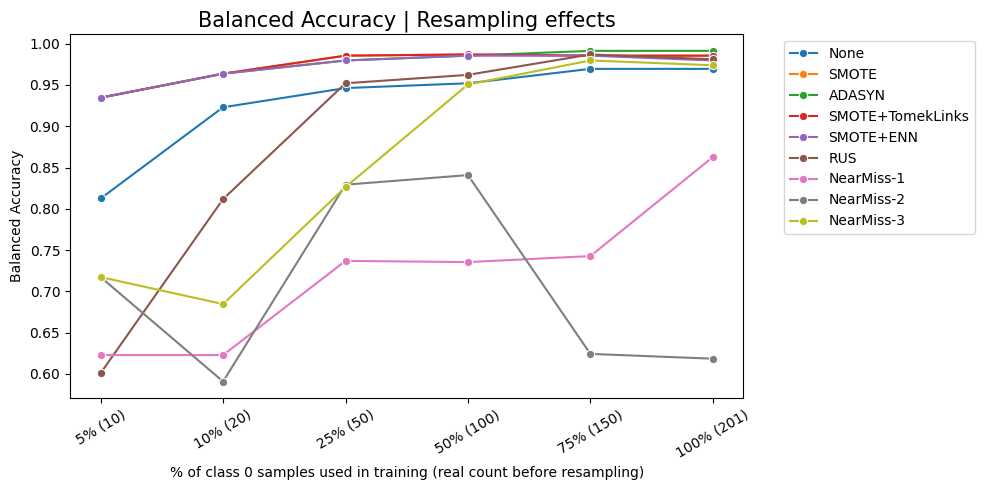

In [141]:
plot_metric(
    BAL_ACC,
    BAL_ACC,
    "Balanced Accuracy | Resampling effects"
)

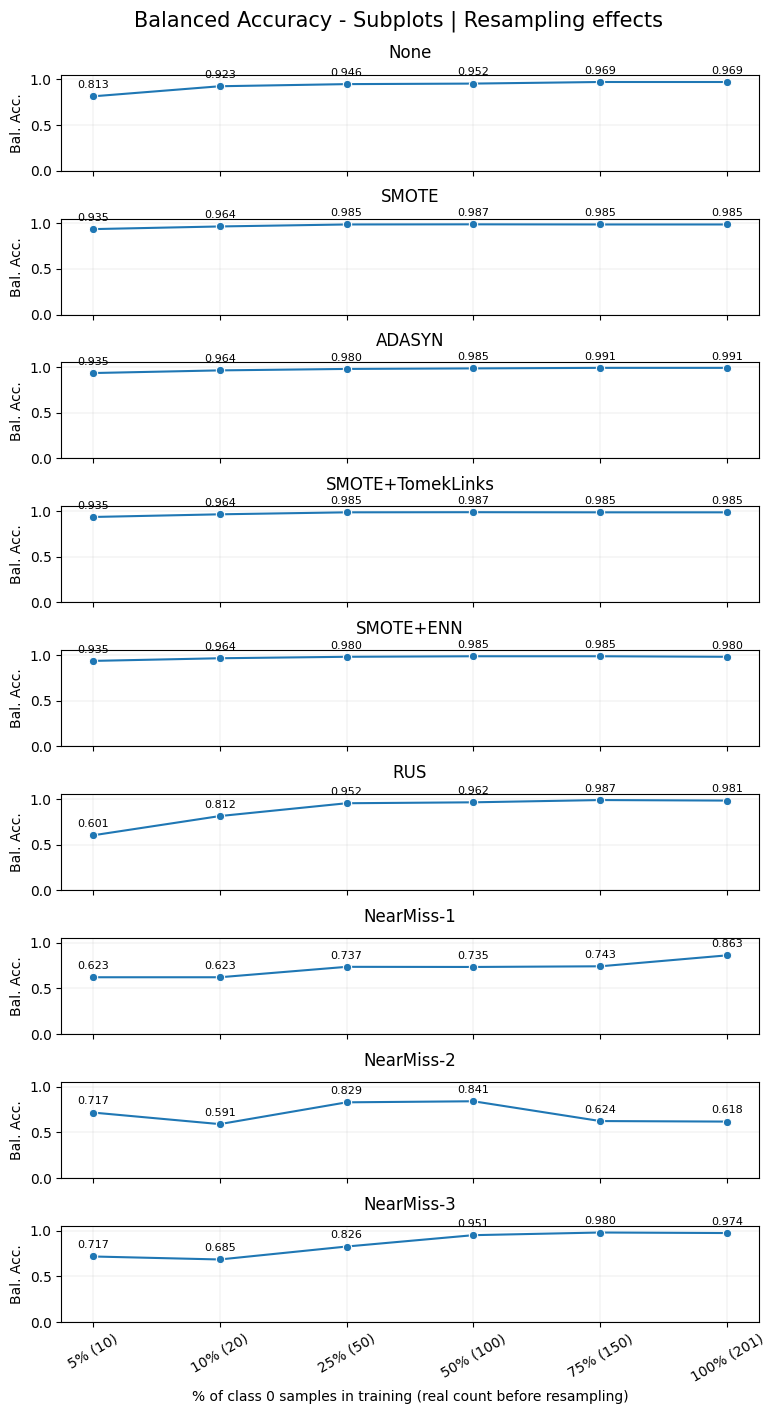

In [142]:
plot_metric_subplots(
    BAL_ACC, 
    "Bal. Acc.", 
    "Balanced Accuracy - Subplots | Resampling effects"
)

### ROC AUC across resampling methods

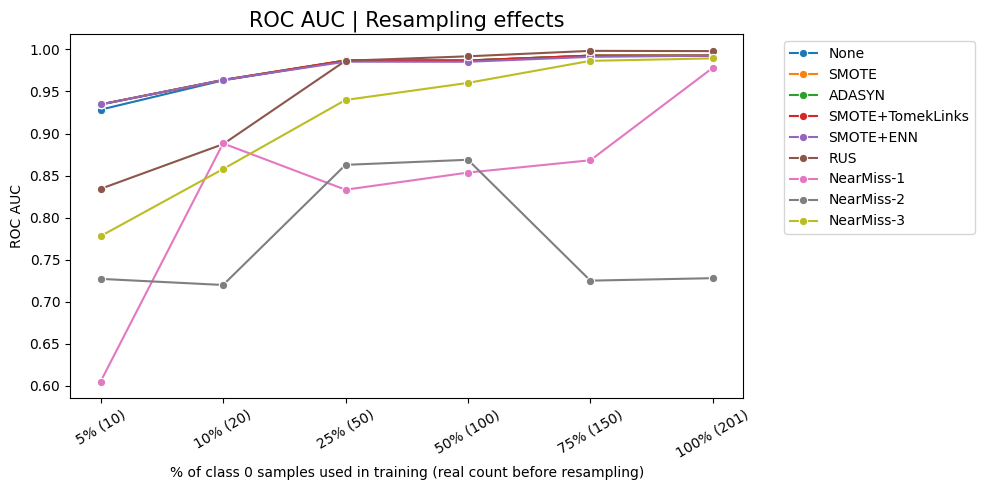

In [143]:
plot_metric(
    ROC_AUC,
    ROC_AUC,
    "ROC AUC | Resampling effects"
)

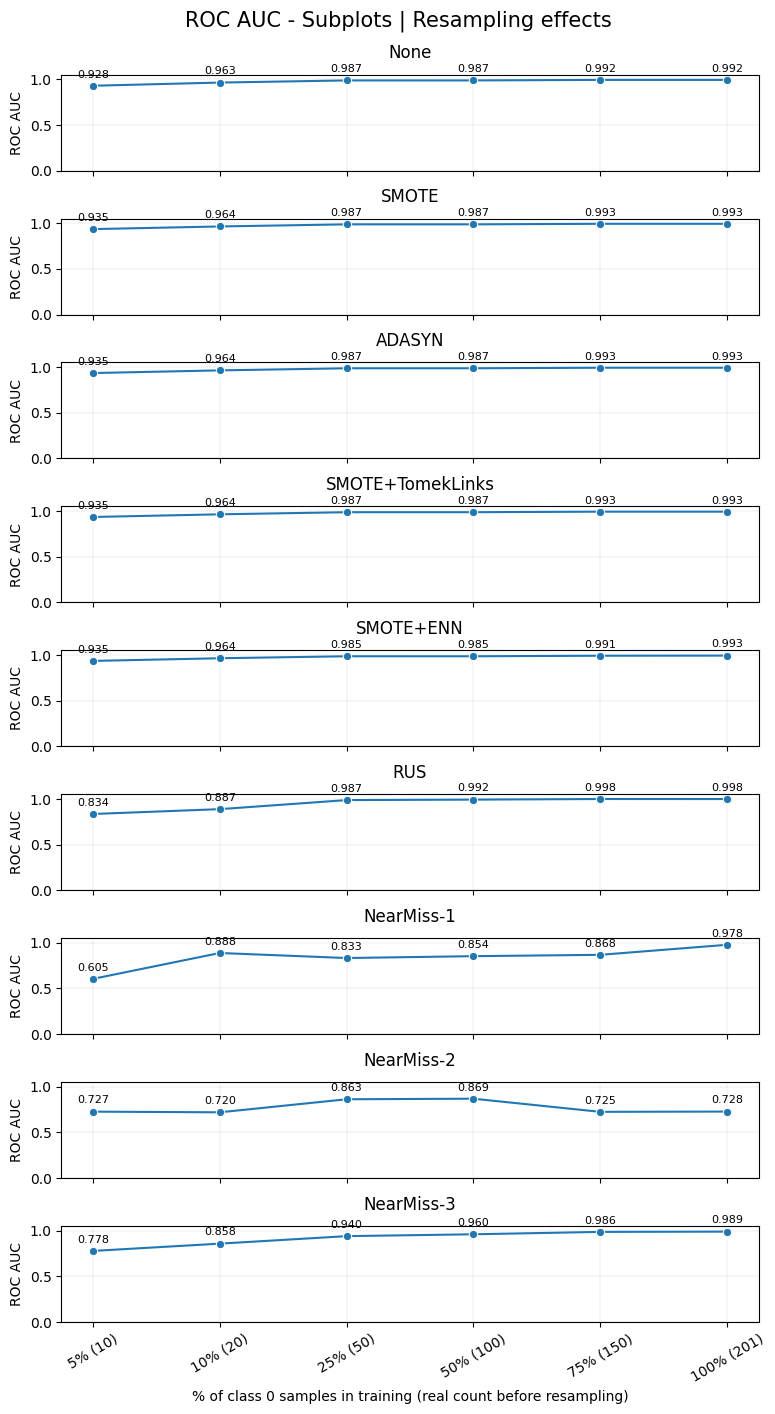

In [144]:
plot_metric_subplots(
    ROC_AUC,
    ROC_AUC,
    "ROC AUC - Subplots | Resampling effects"
)

### Recall of attack class (class 1)

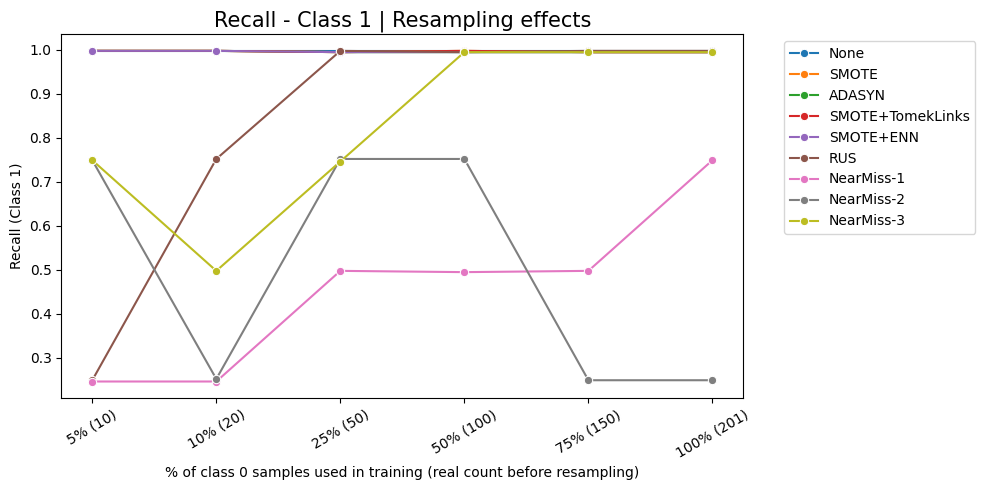

In [145]:
plot_metric(
    REC1,
    REC1,
    "Recall - Class 1 | Resampling effects"
)

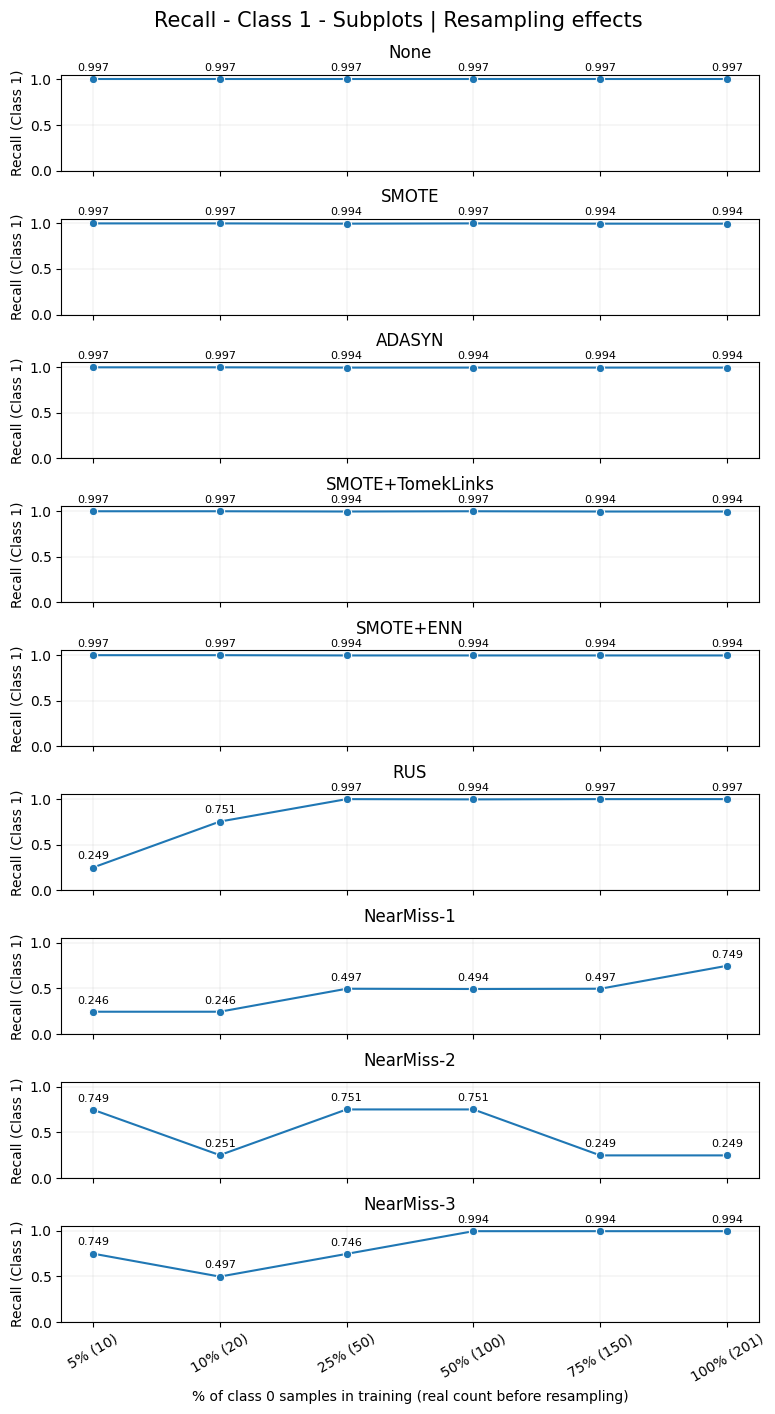

In [146]:
plot_metric_subplots(
    REC1,
    REC1,
    "Recall - Class 1 - Subplots | Resampling effects"
)

### Precision for attack class (class 1)

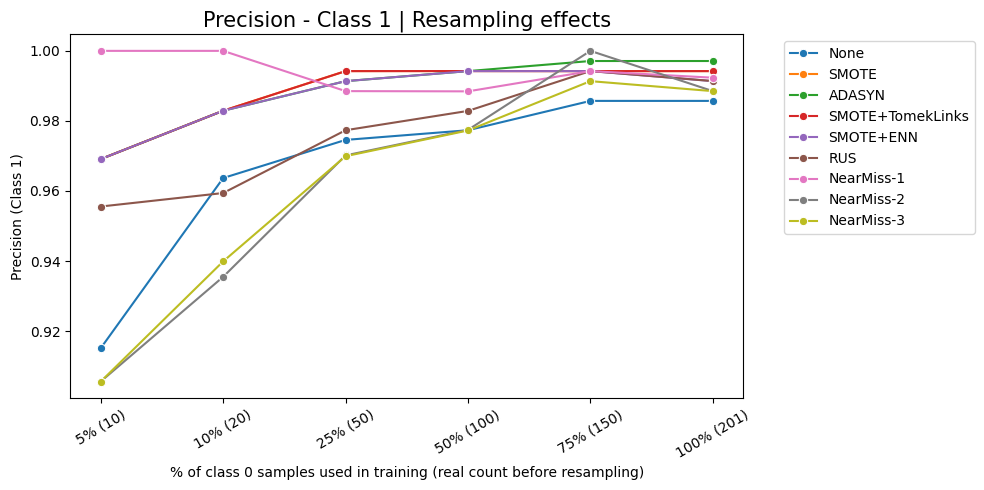

In [147]:
plot_metric(
    PREC1,
    PREC1,
    "Precision - Class 1 | Resampling effects"
)

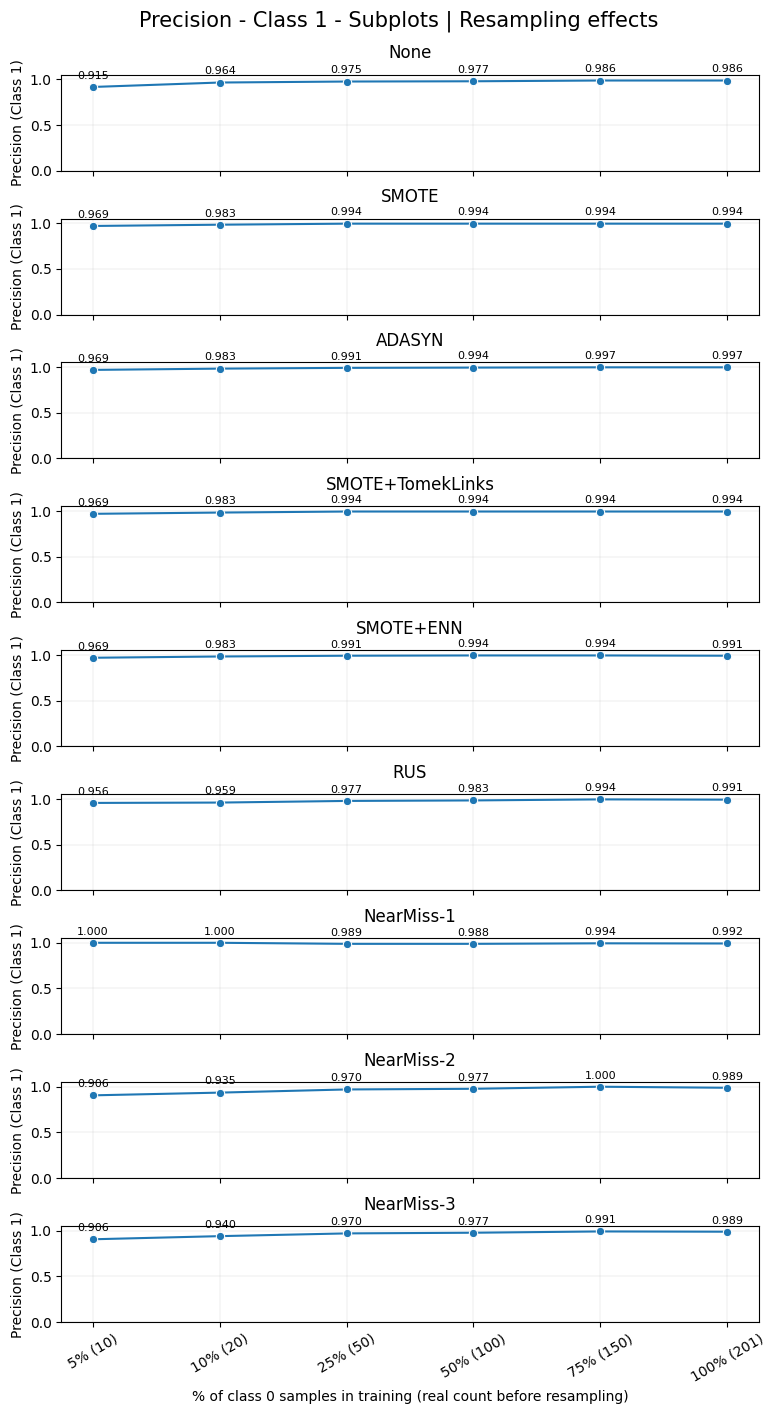

In [148]:
plot_metric_subplots(
    PREC1,
    PREC1,
    "Precision - Class 1 - Subplots | Resampling effects"
)

### F1 score for attack class (class 1)

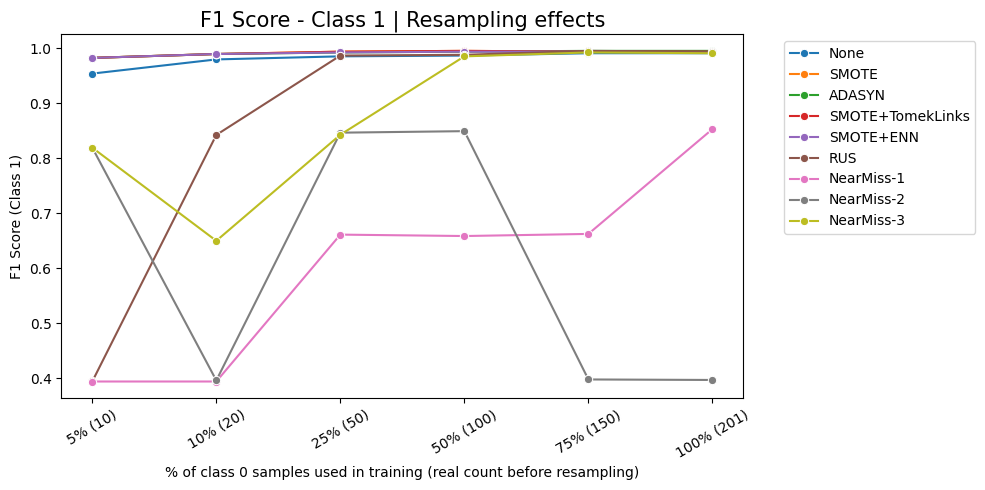

In [149]:
plot_metric(
    F11,
    "F1 Score (Class 1)",
    "F1 Score - Class 1 | Resampling effects"
)

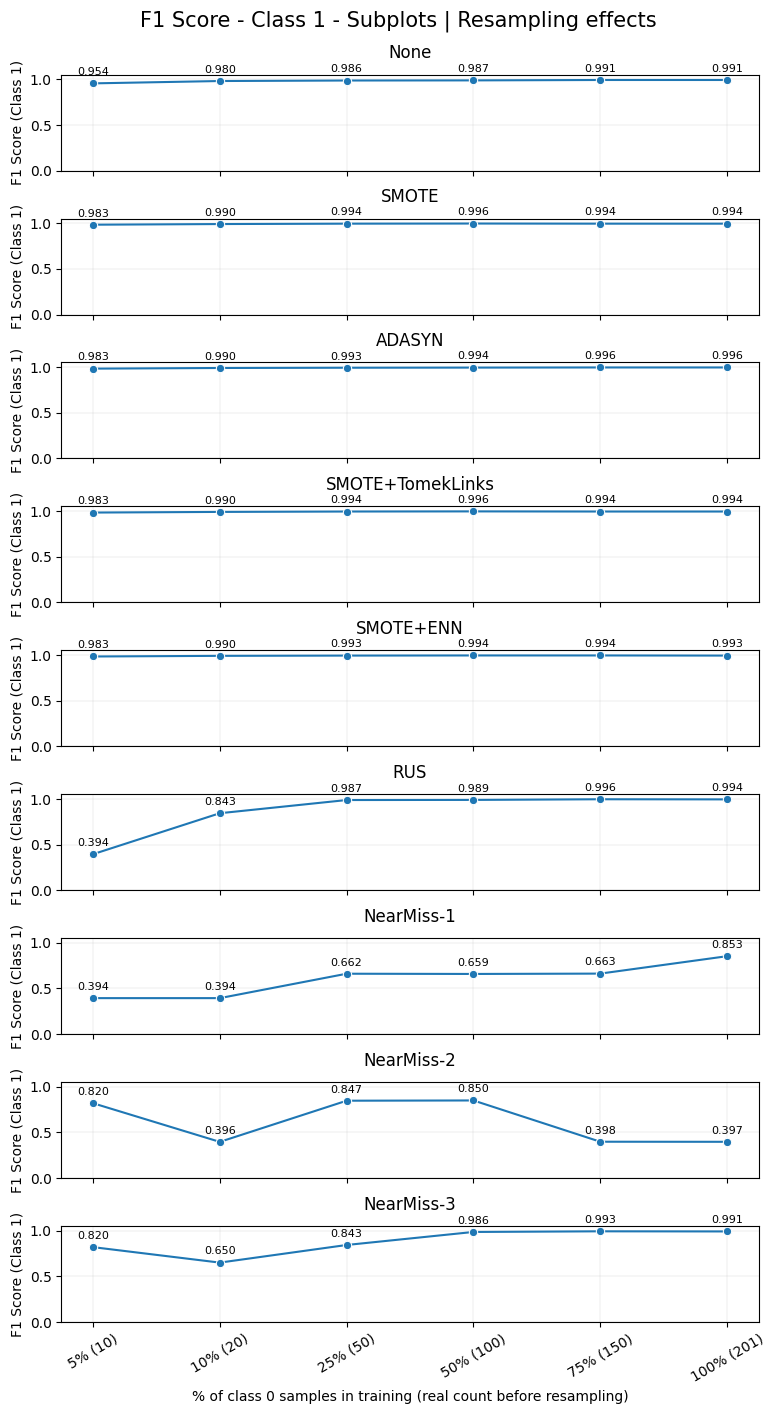

In [150]:
plot_metric_subplots(
    F11,
    "F1 Score (Class 1)",
    "F1 Score - Class 1 - Subplots | Resampling effects"
)

### Recall of normal class (class 0)

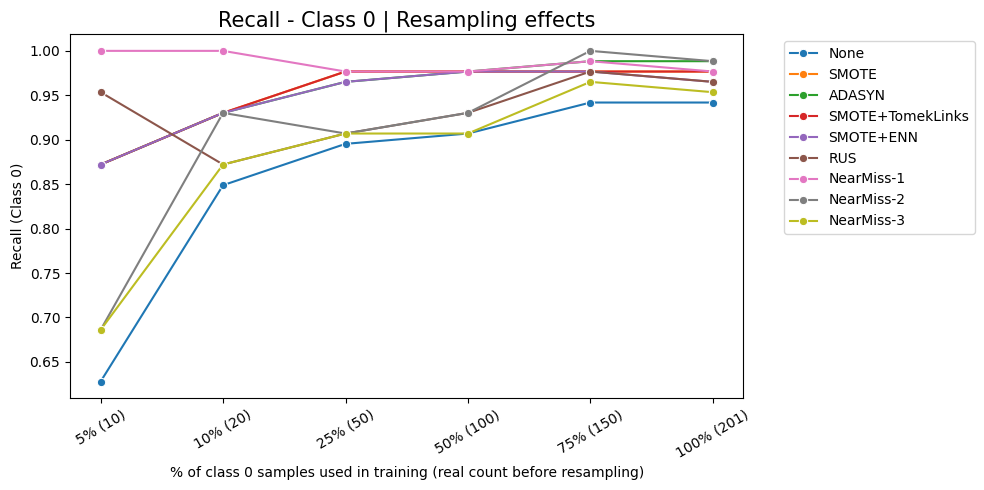

In [151]:
plot_metric(
    REC0,
    REC0,
    "Recall - Class 0 | Resampling effects"
)

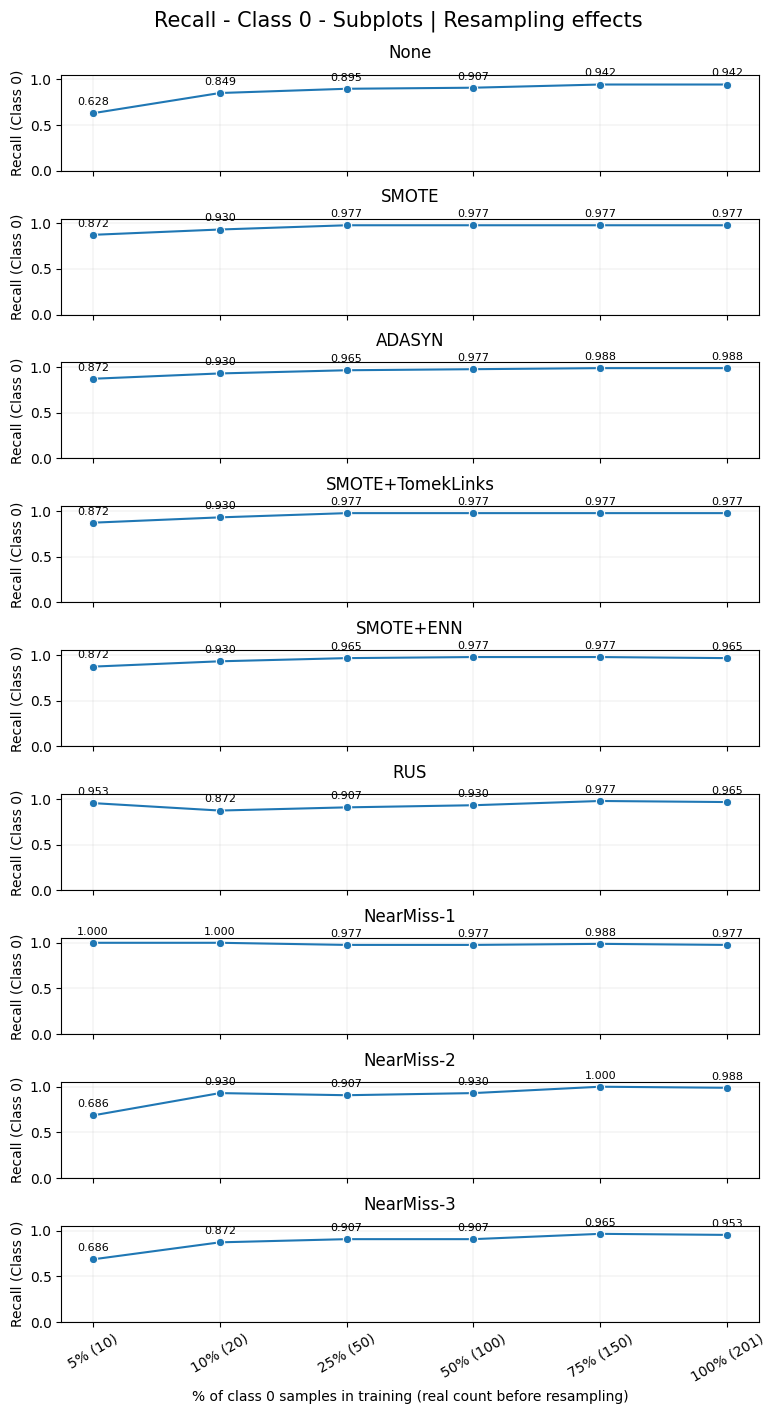

In [152]:
plot_metric_subplots(
    REC0,
    REC0,
    "Recall - Class 0 - Subplots | Resampling effects"
)

### Precision for normal class (class 0)

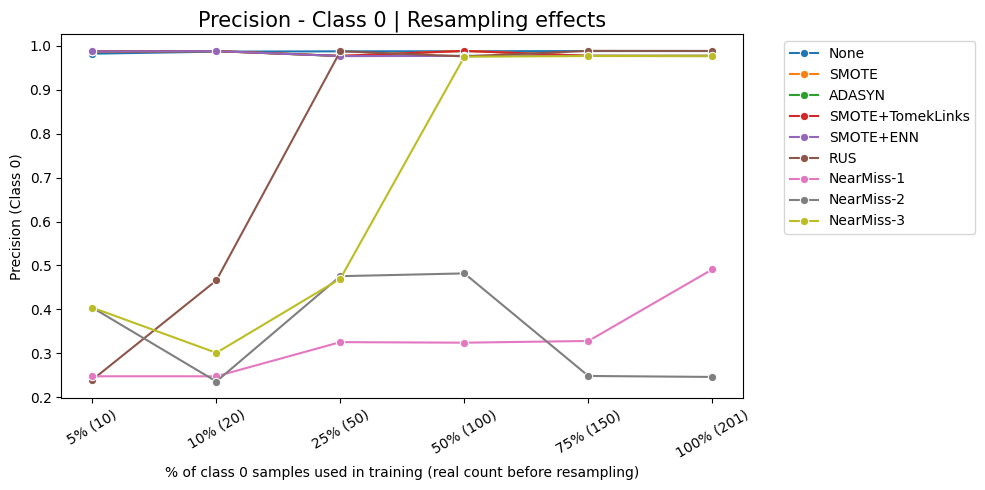

In [153]:
plot_metric(
    PREC0,
    PREC0,
    "Precision - Class 0 | Resampling effects"
)

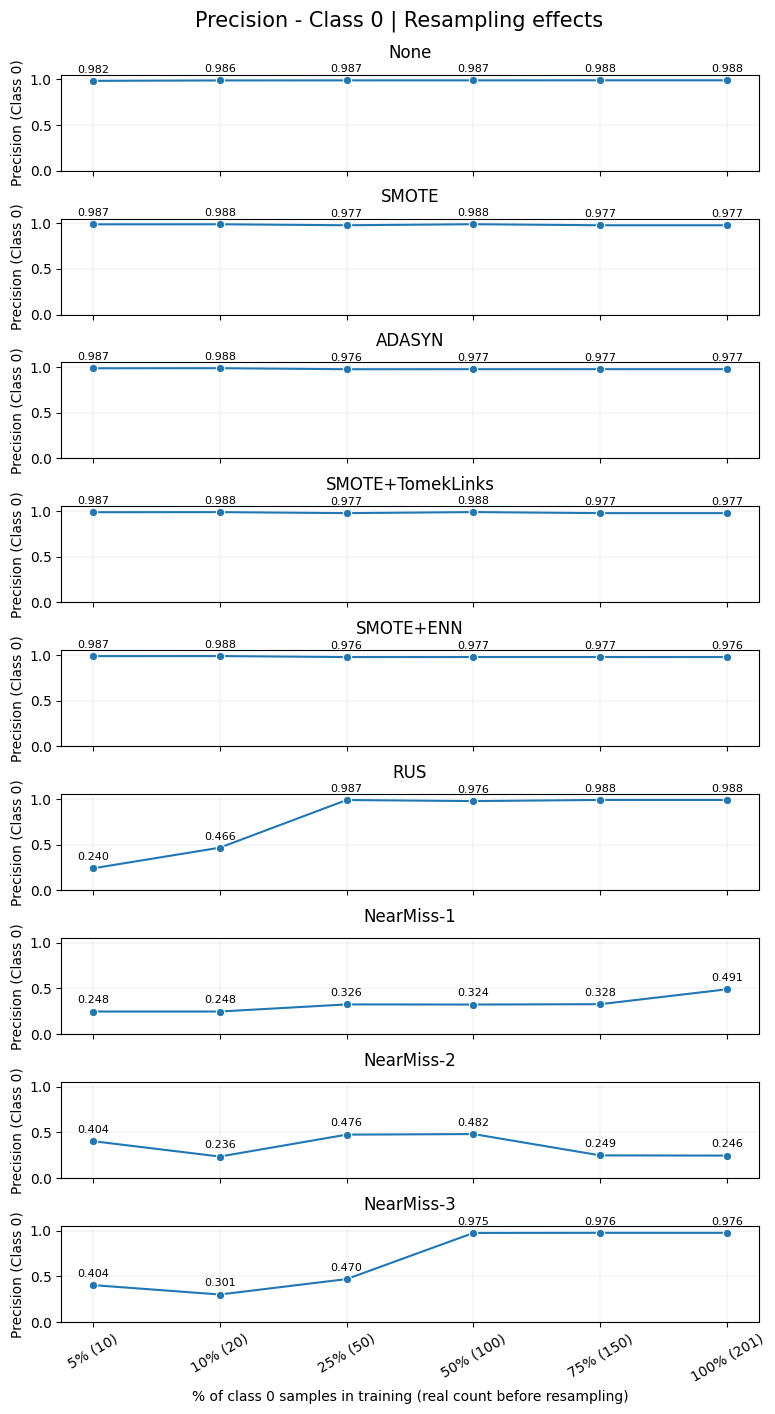

In [154]:
plot_metric_subplots(
    PREC0,
    PREC0,
    "Precision - Class 0 | Resampling effects"
)

### F1 score for normal class (classs 0)

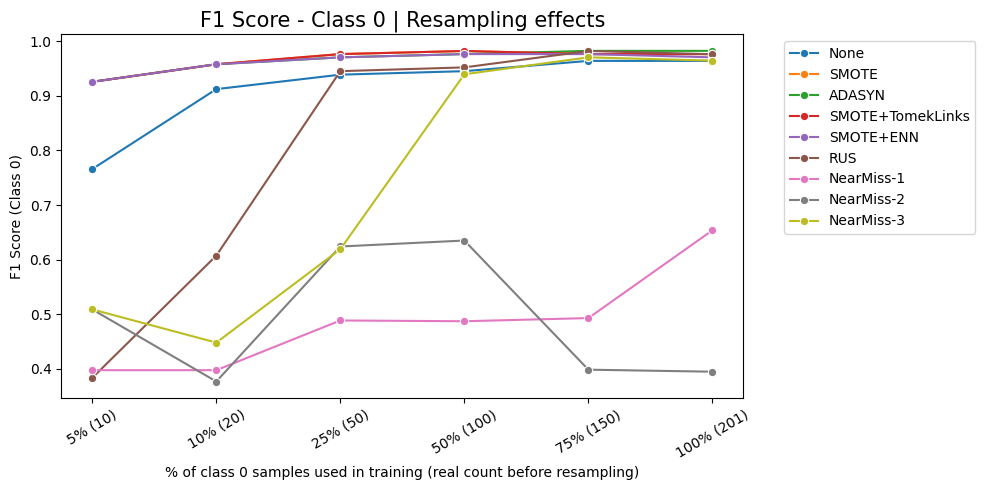

In [155]:
plot_metric(
    F10,
    "F1 Score (Class 0)",
    "F1 Score - Class 0 | Resampling effects"
)

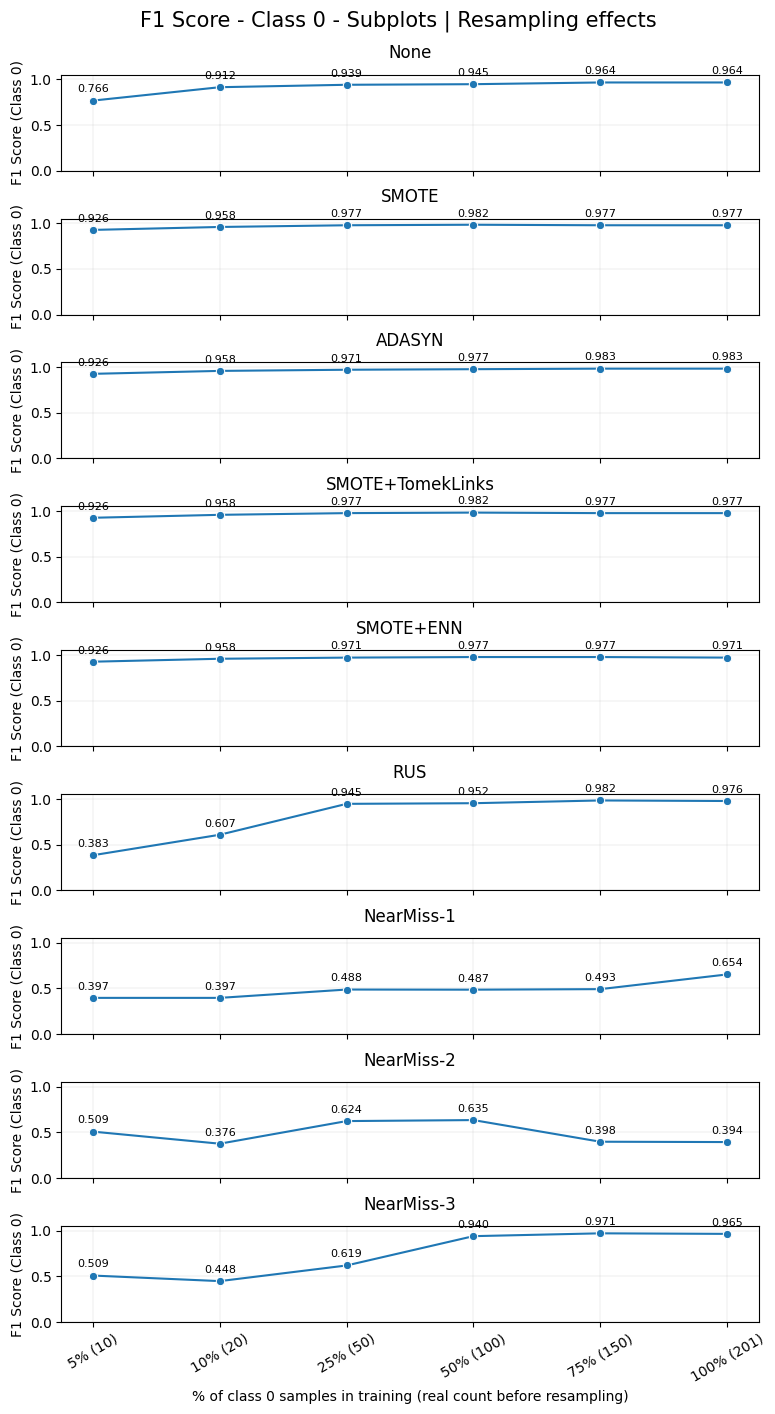

In [156]:
plot_metric_subplots(
    F10,
    "F1 Score (Class 0)",
    "F1 Score - Class 0 - Subplots | Resampling effects"
)

### Accuracy across resampling methods

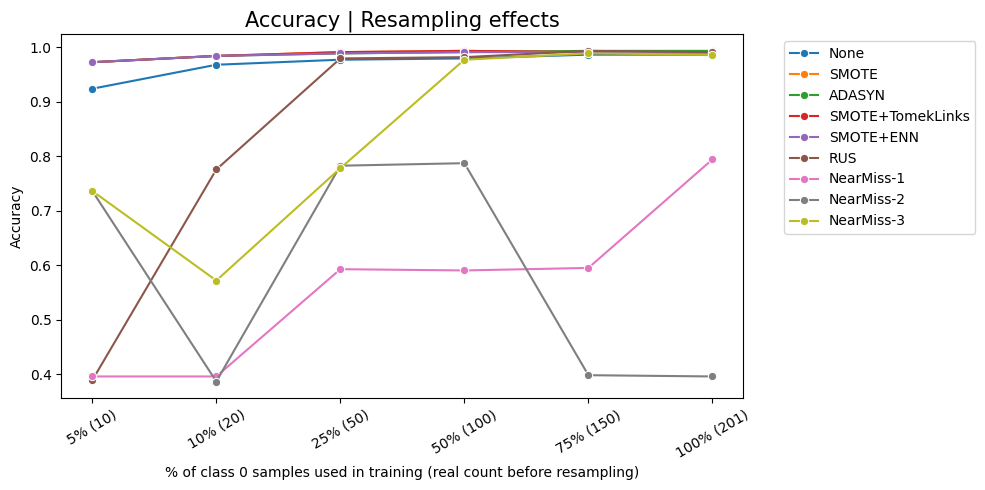

In [157]:
plot_metric(
    ACC,
    ACC,
    "Accuracy | Resampling effects"
)

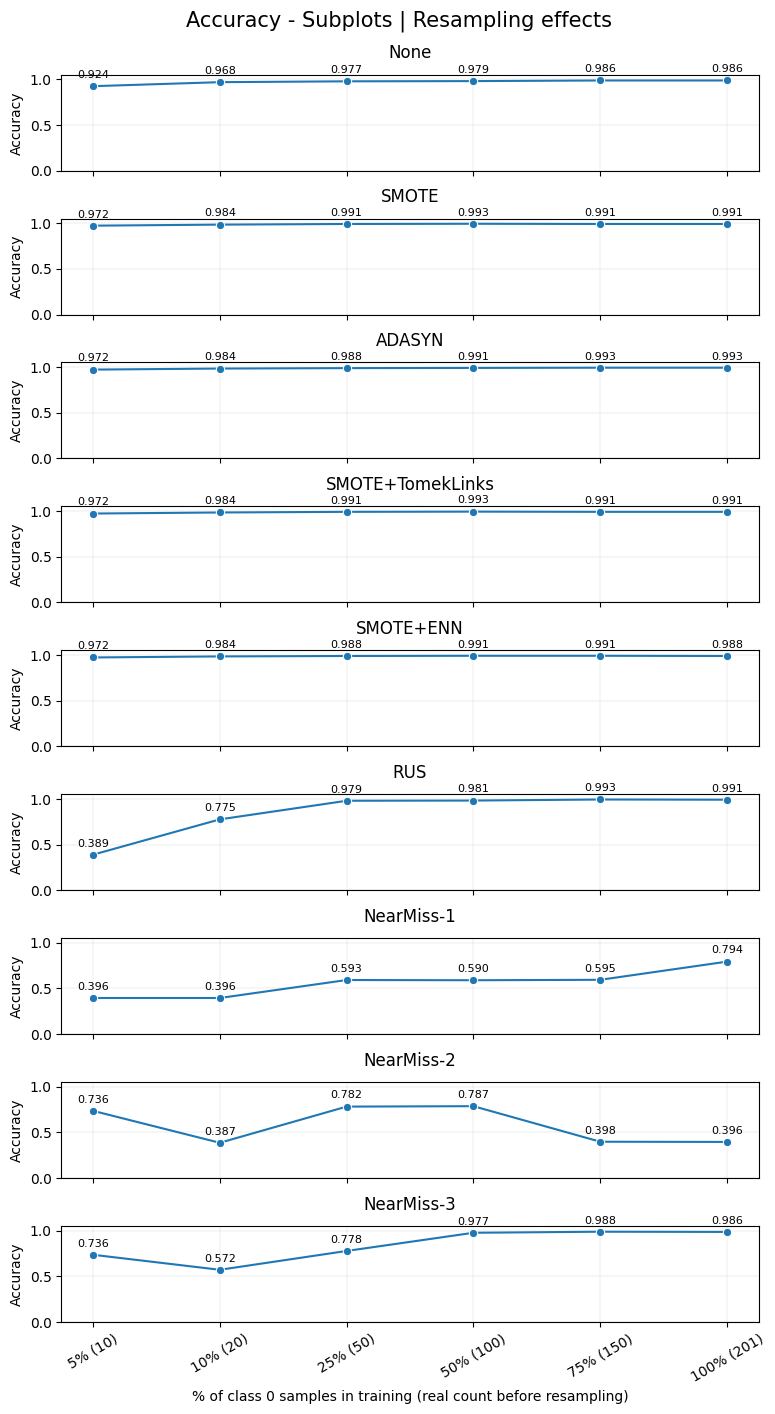

In [158]:
plot_metric_subplots(
    ACC,
    ACC,
    "Accuracy - Subplots | Resampling effects"
)

### Oversampling techniques plot for Recall
Results exported to ``results/oversampling_recall_results.csv``.

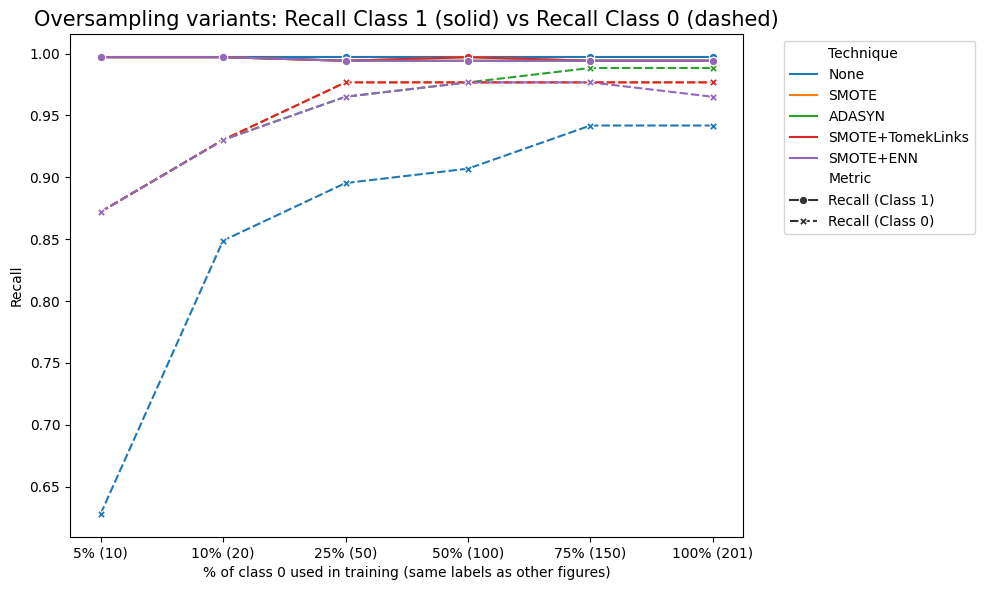

In [159]:
plot_class_metrics_by_sampling(results_df, metric="recall", which="oversampling", include_none=True)

### Oversampling techniques plot for F1-Score
Results exported to ``results/oversampling_f1_results.csv``.

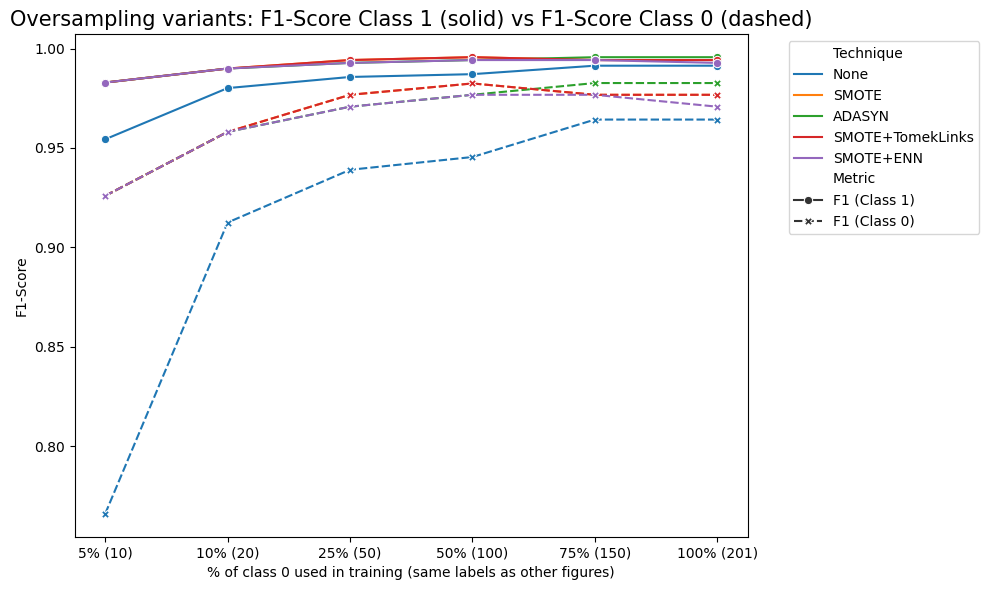

In [160]:
plot_class_metrics_by_sampling(results_df, metric="f1", which="oversampling")

### Undersampling techniques plot for Recall
Results exported to ``undersampling_recall_results.csv``.

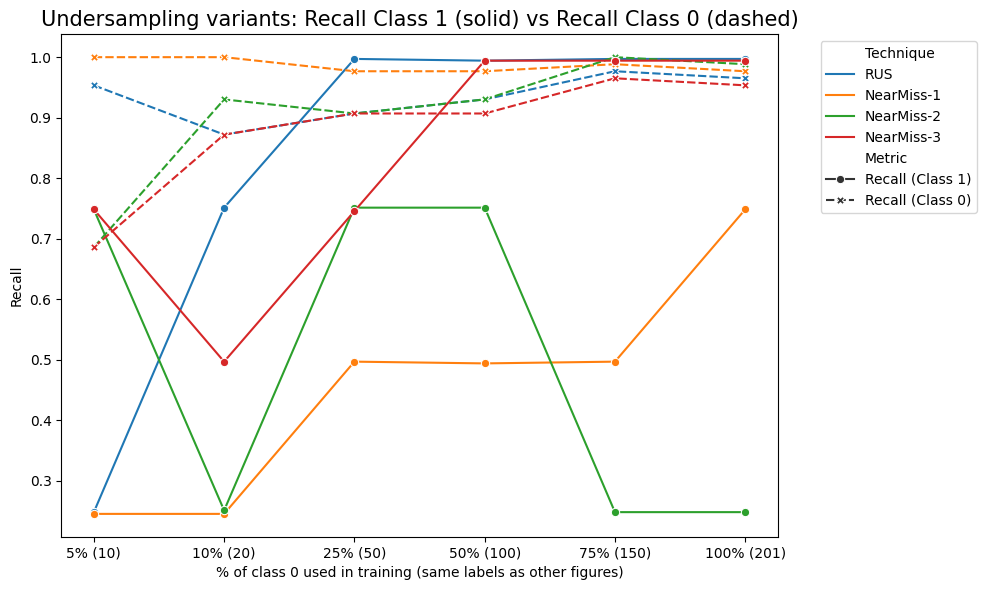

In [161]:
plot_class_metrics_by_sampling(results_df, metric="recall", which="undersampling", include_none=True)

### Undersampling techniques plot for F1-Score
Results exported to ``undersampling_f1_results.csv``.

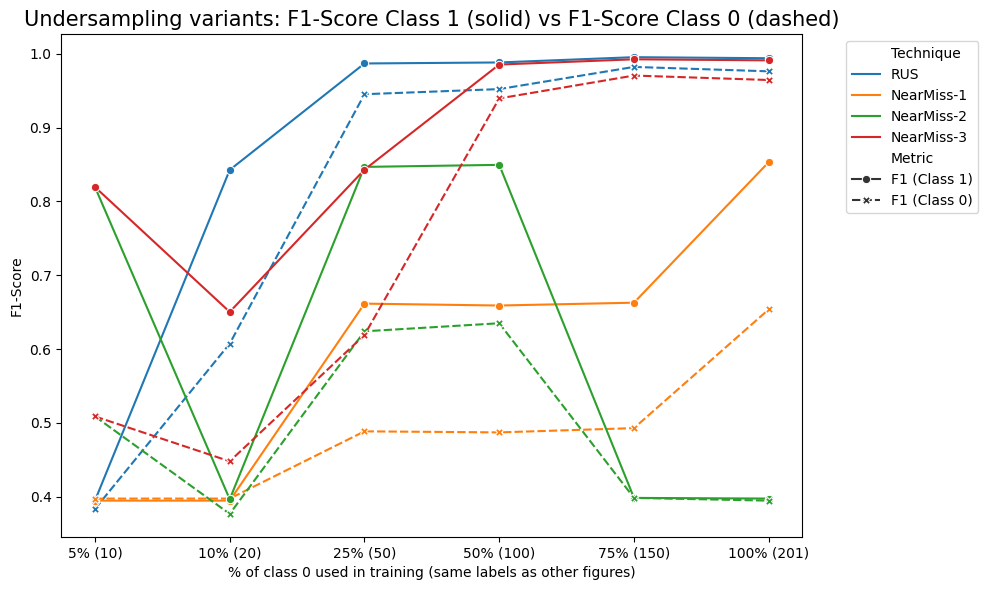

In [162]:
plot_class_metrics_by_sampling(results_df, metric="f1", which="undersampling", include_none=True)

### Resampling counts by technique

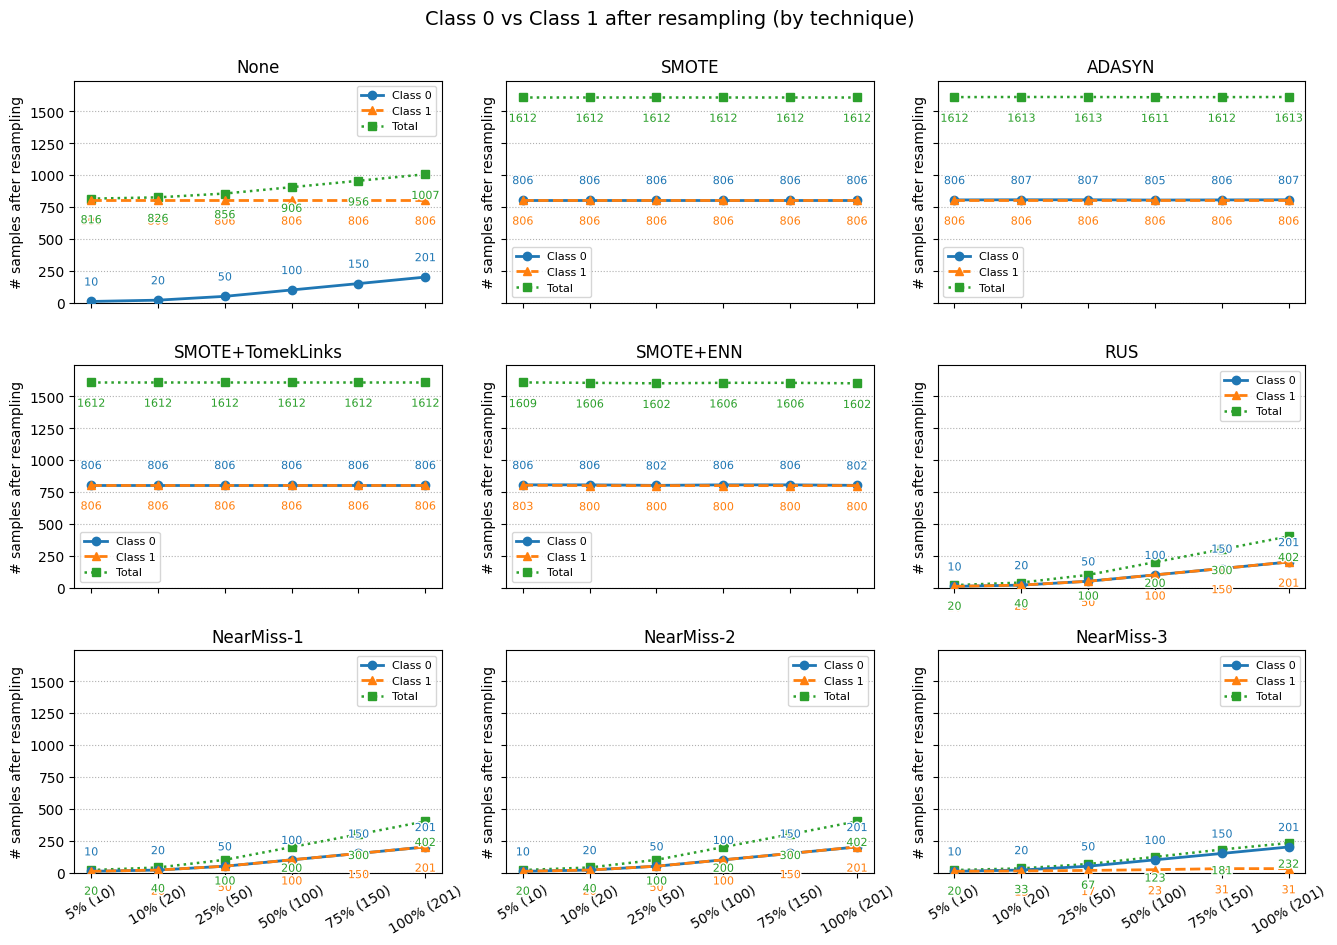

In [163]:
plot_post_resampling_counts_by_technique(results_df, True, True)

### Resampling count for ADASYN

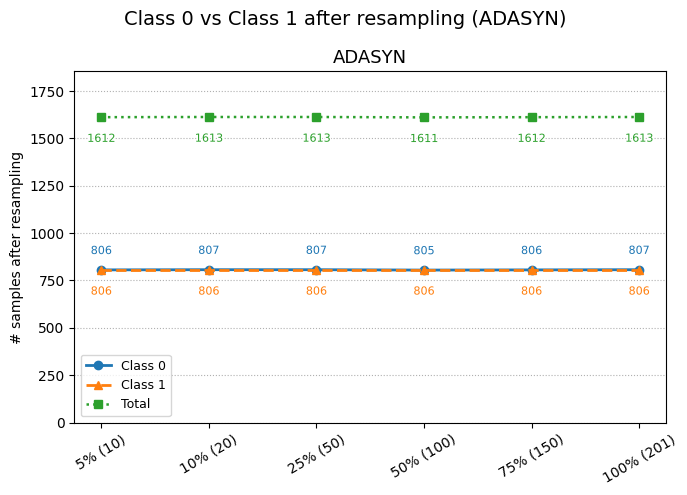

In [164]:
plot_post_resampling_counts_adasyn(results_df, True, True)

### Anex: Final list of features after preprocessing and their meaning according to OCPP 1.6 network traffic

| Feature                                      | Category                     | Meaning in OCPP / network traffic context                                                                 |
|----------------------------------------------|------------------------------|-----------------------------------------------------------------------------------------------------------|
| total_flow_packets                           | Traffic statistics           | Total number of packets in the bidirectional flow.                                                        |
| total_fw_packets                             | Traffic statistics           | Packets sent from client (EVSE / Charge Point) → server.                                                  |
| total_bw_packets                             | Traffic statistics           | Packets sent from server → client (EVSE).                                                                 |
| flow_duration                                | Temporal metric              | Duration of the flow (seconds between first and last packet).                                              |
| flow_down_up_ratio                           | Traffic statistics           | Ratio of downlink vs uplink packets.                                                                      |
| flow_total_SYN_flag                          | TCP indicator                | Number of TCP packets with SYN flag (connection establishment).                                            |
| flow_total_RST_flag                          | TCP indicator                | Number of TCP packets with RST flag (connection reset).                                                    |
| flow_total_PSH_flag                          | TCP indicator                | Packets with PSH flag (push function, deliver immediately).                                                |
| flow_total_ACK_flag                          | TCP indicator                | Number of TCP packets with ACK flag (acknowledgements).                                                    |
| flow_total_FIN_flag                          | TCP indicator                | Number of TCP packets with FIN flag (connection termination).                                              |
| flow_total_http_get_packets                  | HTTP indicator               | Number of HTTP GET request packets (used in REST OCPP bindings).                                           |
| flow_total_http_2xx_packets                  | HTTP indicator               | HTTP responses with status 2xx (success).                                                                 |
| flow_total_http_4xx_packets                  | HTTP indicator               | HTTP responses with status 4xx (client error).                                                            |
| flow_websocket_packts_per_second             | WebSocket metric             | WebSocket packet rate per second (bidirectional).                                                          |
| fw_websocket_packts_per_second               | WebSocket metric             | WebSocket packet rate per second client → server.                                                          |
| bw_websocket_packts_per_second               | WebSocket metric             | WebSocket packet rate per second server → client.                                                          |
| flow_websocket_bytes_per_second              | WebSocket metric             | WebSocket throughput in bytes per second (bidirectional).                                                  |
| fw_websocket_bytes_per_second                | WebSocket metric             | WebSocket throughput bytes/sec client → server.                                                            |
| bw_websocket_bytes_per_second                | WebSocket metric             | WebSocket throughput bytes/sec server → client.                                                            |
| flow_total_websocket_ping_packets            | WebSocket control            | Number of WebSocket **ping** control frames (keep-alive).                                                  |
| flow_total_websocket_pong_packets            | WebSocket control            | Number of WebSocket **pong** control frames (responses to ping).                                           |
| flow_total_websocket_close_packets           | WebSocket control            | Number of WebSocket close frames (graceful session termination).                                           |
| flow_total_websocket_data_messages           | WebSocket data               | Number of WebSocket **application data** messages (JSON OCPP frames).                                      |
| flow_total_ocpp16_heartbeat_packets          | OCPP 1.6 message             | Number of **Heartbeat** messages sent (keep-alive from EVSE to server).                                    |
| flow_total_ocpp16_starttransaction_packets   | OCPP 1.6 message             | Number of **StartTransaction** messages (session initiation).                                              |
| flow_total_ocpp16_remotestarttransaction_packets | OCPP 1.6 message         | Number of **RemoteStartTransaction** messages (server request to EVSE).                                    |
| flow_total_ocpp16_authorize_not_accepted_packets | OCPP 1.6 message         | Number of **Authorize** messages with rejected status.                                                     |
| flow_total_ocpp16_setchargingprofile_packets | OCPP 1.6 message             | Number of **SetChargingProfile** requests (limit charging parameters).                                     |
| flow_avg_ocpp16_setchargingprofile_limit     | OCPP charging profile metric | Average charging limit value in **SetChargingProfile** messages.                                           |
| flow_max_ocpp16_setchargingprofile_limit     | OCPP charging profile metric | Maximum charging limit value in **SetChargingProfile** messages.                                           |
| flow_min_ocpp16_setchargingprofile_limit     | OCPP charging profile metric | Minimum charging limit value in **SetChargingProfile** messages.                                           |
| flow_avg_ocpp16_setchargingprofile_minchargingrate | OCPP charging profile metric | Average **minChargingRate** in SetChargingProfile messages.                                               |
| flow_min_ocpp16_setchargingprofile_minchargingrate | OCPP charging profile metric | Minimum **minChargingRate** in SetChargingProfile messages.                                               |
| flow_max_ocpp16_setchargingprofile_minchargingrate | OCPP charging profile metric | Maximum **minChargingRate** in SetChargingProfile messages.                                               |
| flow_total_ocpp16_metervalues                | OCPP 1.6 message             | Number of **MeterValues** messages (energy consumption, Wh).                                               |
| flow_avg_ocpp16_metervalues_wh_diff          | OCPP metering metric         | Average Wh difference reported in MeterValues messages.                                                    |
| flow_max_ocpp16_metervalues_wh_diff          | OCPP metering metric         | Maximum Wh difference reported in MeterValues messages.                                                    |
| flow_min_ocpp16_metervalues_wh_diff          | OCPP metering metric         | Minimum Wh difference reported in MeterValues messages.                                                    |

### Labels used for classification (not part of OCPP)
| Feature      | Category   | Meaning                                                                 |
|--------------|------------|-------------------------------------------------------------------------|
| label        | Label      | Original flow label (Normal or specific attack type).                   |
| label_bin    | Label      | Binary label: 0 = Normal, 1 = Attack.                                   |
